# Projeto 5.8 — Detecção de Anomalias em Transações em Python

**Bootcamp Bradesco — GenAI, Dados & Cyber — Módulo 05**

## Objetivo

Desenvolver um fluxo reprodutível para análise e detecção de transações potencialmente fraudulentas, aplicando técnicas de exploração, preparação de dados, classificação, avaliação de modelos e explicabilidade.

O processo contempla:

1. carregamento e validação dos dados;
2. análise exploratória;
3. limpeza e transformação;
4. separação entre treino e teste;
5. construção de um modelo baseline;
6. avaliação adequada para dados desbalanceados;
7. comparação de estratégias de balanceamento e modelos;
8. explicabilidade dos resultados;
9. conclusão técnica e limitações.

## Integração com o Módulo 05

O projeto 5.8 consolida, em um único fluxo, conceitos trabalhados ao longo do Módulo 05:

| Referência | Aplicação no projeto |
|---|---|
| **5.1 — Arquivos e dados externos** | obtenção e leitura do arquivo CSV e organização da fonte de dados |
| **5.2 — Tratamento de erros e robustez** | exceções, validações, mensagens de erro e logging |
| **5.3 — NumPy, Pandas e análise de dados** | manipulação do `DataFrame`, inspeção, estatísticas e análise exploratória |
| **5.4 — Limpeza e transformação de dados** | diagnóstico de qualidade, tratamento, transformação e padronização |
| **5.5 — Automação e pipelines** | organização do fluxo, reprodutibilidade e rastreabilidade |
| **5.6 — Visualização e storytelling** | construção e interpretação de visualizações |
| **5.7 — Qualidade de código e métricas** | Clean Code, funções reutilizáveis, verificações, desempenho e métricas |
| **5.8 — Detecção de anomalias em transações** | desbalanceamento, classificação de fraude, comparação de modelos, ajuste de limiar e explicabilidade |

Essa integração permite relacionar cada etapa prática do notebook aos conceitos desenvolvidos nas atividades anteriores do módulo.

In [ ]:
# 0. Ambiente — execute esta célula primeiro.
# Importa bibliotecas gerais e define funções auxiliares de apresentação.

import logging

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    average_precision_score,
)

RANDOM_STATE = 42

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s"
)


logging.info("Ambiente carregado.")


## 1. Coleta e carregamento dos dados

Esta etapa estabelece a entrada de dados do projeto de forma **reprodutível e verificável**, antes de qualquer análise ou transformação.

**Dataset utilizado:** `creditcard.csv`  
**Endereço de acesso:** `https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv`

### Referências ao Módulo 05

- **5.1 — Arquivos e dados externos:** leitura de um arquivo CSV obtido de fonte externa;
- **5.2 — Tratamento de erros e robustez:** uso de `try/except` e interrupção explícita quando o carregamento falha;
- **5.7 — Qualidade de código:** constantes, nomes descritivos e validações antecipadas.

**Critério desta etapa:** confirmar apenas que o arquivo pode ser carregado e que a estrutura mínima necessária ao fluxo está presente. A inspeção detalhada e a qualidade dos dados são tratadas nas etapas seguintes.


### 1.1 Carregamento e validação mínima do dataset

O arquivo é carregado com `pandas.read_csv()`. Em seguida, o notebook verifica a presença de `Time`, `Amount` e `Class`, definidas como colunas mínimas necessárias para o fluxo.

Se o carregamento falhar ou alguma dessas colunas estiver ausente, a execução é interrompida com uma mensagem explícita. Ao final, `df.head()` exibe uma amostra inicial do conteúdo carregado.


In [ ]:
# 1.1 Carregamento e validação mínima do dataset

DATA_URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
COLUNAS_OBRIGATORIAS = {"Time", "Amount", "Class"}

try:
    df = pd.read_csv(DATA_URL)
except Exception as exc:
    raise RuntimeError("Não foi possível carregar o dataset pela fonte configurada.") from exc

colunas_ausentes = COLUNAS_OBRIGATORIAS.difference(df.columns)
if colunas_ausentes:
    raise ValueError(f"Dataset incompatível. Colunas obrigatórias ausentes: {sorted(colunas_ausentes)}")

logging.info("Dataset carregado e estrutura mínima validada.")
display(df.head())


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


**Variáveis principais e convenções de leitura**

| Variável | Como interpretar | Convenção adotada no notebook |
|---|---|---|
| `Time` | segundos transcorridos desde a primeira transação registrada | o dado bruto permanece em segundos; tabelas e gráficos usam **horas** quando isso melhora a leitura |
| `Amount` | valor da transação | exibido com **duas casas decimais**; a fonte disponível não informa a moeda, portanto nenhum símbolo monetário é assumido |
| `V1` a `V28` | componentes numéricos transformados por PCA para preservar a confidencialidade das variáveis originais | não possuem significado de negócio individual divulgado; serão avaliados por padrões estatísticos, modelagem e explicabilidade |
| `Class` | variável-alvo | `0` = transação normal; `1` = fraude |

**Padrão visual:** contagens são apresentadas como inteiros com separador de milhar; valores de `Amount` usam duas casas decimais; percentuais preservam casas adicionais quando necessário para representar a classe rara.

Essas conversões são apenas de **apresentação** e não alteram os valores originais armazenados em `df`.


## 2. Inspeção estrutural do dataset

Depois de confirmar o carregamento, esta etapa descreve **como o conjunto de dados está estruturado** antes de qualquer limpeza, transformação ou modelagem.

### Referências ao Módulo 05

- **5.3 — NumPy, Pandas e análise de dados:** inspeção do `DataFrame` por propriedades e métodos do Pandas;
- **5.8 — Detecção de anomalias em transações:** confirmação da estrutura efetivamente disponível para o problema de classificação.

**Critério desta etapa:** descrever dimensões, variáveis e tipos sem alterar o dataset. Questões de qualidade são tratadas na etapa 3.


### 2.1 Inspeção estrutural

A inspeção verifica:

- quantidade de linhas e colunas;
- nomes e tipos das variáveis;
- sequência das variáveis anonimizadas `V`;
- tipo e valores distintos da variável-alvo `Class`.

O objetivo é confirmar a estrutura real do arquivo carregado e evitar que decisões posteriores dependam apenas de exemplos ou descrições externas.


In [ ]:
# 2.1 Inspeção estrutural

linhas_formatadas = f"{df.shape[0]:,}".replace(",", ".")
print(f"Dimensões: {linhas_formatadas} linhas × {df.shape[1]} colunas")

print("\nColunas do dataset:")
print(df.columns.tolist())

print("\nResumo estrutural:")
df.info()

variaveis_v = sorted(
    [c for c in df.columns if c.startswith("V") and c[1:].isdigit()],
    key=lambda c: int(c[1:])
)

if variaveis_v:
    print(
        f"\nVariáveis anonimizadas detectadas: "
        f"{variaveis_v[0]} até {variaveis_v[-1]} "
        f"({len(variaveis_v)} colunas)"
    )

print(f"Tipo de 'Class': {df['Class'].dtype}")
print("Valores distintos em 'Class':", sorted(df["Class"].dropna().unique().tolist()))

Dimensões: 284.807 linhas × 31 colunas

Colunas do dataset:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Resumo estrutural:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-

## 3. Qualidade inicial dos dados

Antes de qualquer limpeza, transformação ou modelagem, esta etapa avalia a qualidade inicial do conjunto de dados e caracteriza situações que podem influenciar as decisões posteriores. O diagnóstico é dividido em duas verificações complementares, detalhadas nas subseções 3.1 e 3.2.

### Referências ao Módulo 05

- **5.4 — Limpeza e transformação de dados:** diagnóstico de qualidade antes de decidir qualquer tratamento;
- **5.7 — Qualidade de código:** validações explícitas, separação entre diagnóstico e tratamento e apresentação organizada dos resultados.

**Critério desta etapa:** identificar e caracterizar problemas sem alterar o dataset. Nenhuma linha é removida nesta fase. Qualquer tratamento deverá ser justificado pelo contexto, pelo possível impacto sobre treino e teste e pelas análises seguintes.

A distribuição geral de `Class` será analisada separadamente na etapa 4, enquanto estatísticas descritivas e amplitudes das variáveis serão exploradas na etapa 5.


### 3.1 Diagnóstico geral de qualidade

A primeira verificação mede a qualidade básica do dataset sem realizar qualquer tratamento. São observados:

- valores ausentes e sua proporção por variável;
- quantidade de valores válidos distintos;
- duplicatas excedentes, isto é, repetições além da primeira ocorrência de uma linha;
- valores infinitos nas colunas numéricas.

**Objetivo:** identificar problemas objetivos de qualidade e dimensionar sua ocorrência antes de decidir qualquer intervenção sobre os dados.


In [ ]:
# 3.1 Diagnóstico geral de qualidade

qualidade = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_pct": (df.isna().mean() * 100).round(4),
    "unicos": df.nunique(dropna=True)
})

display(qualidade)

duplicatas = int(df.duplicated().sum())
duplicatas_pct = (duplicatas / len(df)) * 100

numeric_df = df.select_dtypes(include=np.number)
infinitos = int(np.isinf(numeric_df).sum().sum())

print(f"Linhas duplicadas: {duplicatas:,} ({duplicatas_pct:.4f}%)")
print(f"Valores infinitos em colunas numéricas: {infinitos:,}")


,dtype,nulos,nulos_pct,unicos
Time,float64,0,0.0,124592
V1,float64,0,0.0,275663
V2,float64,0,0.0,275663
V3,float64,0,0.0,275663
V4,float64,0,0.0,275663
V5,float64,0,0.0,275663
V6,float64,0,0.0,275663
V7,float64,0,0.0,275663
V8,float64,0,0.0,275663
V9,float64,0,0.0,275663


Linhas duplicadas: 1,081 (0.3796%)
Valores infinitos em colunas numéricas: 0


### 3.2 Análise das linhas duplicadas

Nesta etapa, `df.duplicated()` é aprofundado sem excluir registros. Duas linhas só são consideradas duplicadas quando **todas as colunas comparadas apresentam os mesmos valores**.

A análise distingue dois conceitos:

- **duplicatas excedentes:** repetições além da primeira ocorrência de cada registro;
- **linhas em grupos duplicados:** inclui tanto a primeira ocorrência quanto suas repetições.

Essa distinção é importante porque o número de duplicatas excedentes não informa, sozinho, quantos registros estão envolvidos nem como essas repetições se distribuem entre as classes `0` e `1`.

**Objetivo:** caracterizar a duplicação antes de decidir qualquer tratamento. Nenhuma linha será removida nesta célula.


In [ ]:
# 3.2 Análise das linhas duplicadas

mask_duplicatas_excedentes = df.duplicated(keep="first")
mask_grupos_duplicados = df.duplicated(keep=False)

duplicatas_excedentes = int(mask_duplicatas_excedentes.sum())
linhas_em_grupos_duplicados = int(mask_grupos_duplicados.sum())
linhas_distintas = int(len(df.drop_duplicates()))

# Como o filtro abaixo contém apenas linhas envolvidas em duplicação,
# o agrupamento por todas as colunas fica restrito a esse subconjunto.
tamanhos_grupos = (
    df.loc[mask_grupos_duplicados]
      .groupby(list(df.columns), dropna=False)
      .size()
      .sort_values(ascending=False)
)

grupos_duplicados = int(len(tamanhos_grupos))
maior_repeticao = int(tamanhos_grupos.max()) if grupos_duplicados else 0

resumo_duplicatas = pd.DataFrame({
    "metrica": [
        "linhas_totais",
        "linhas_distintas",
        "duplicatas_excedentes",
        "linhas_em_grupos_duplicados",
        "grupos_duplicados_distintos",
        "maior_numero_de_ocorrencias_em_um_grupo",
    ],
    "valor": [
        len(df),
        linhas_distintas,
        duplicatas_excedentes,
        linhas_em_grupos_duplicados,
        grupos_duplicados,
        maior_repeticao,
    ],
})

display(resumo_duplicatas)

# Distribuição das duplicatas pela variável-alvo.
contagem_classe = df["Class"].value_counts().sort_index()
excedentes_por_classe = (
    df.loc[mask_duplicatas_excedentes, "Class"]
      .value_counts()
      .reindex(contagem_classe.index, fill_value=0)
      .sort_index()
)
linhas_grupos_por_classe = (
    df.loc[mask_grupos_duplicados, "Class"]
      .value_counts()
      .reindex(contagem_classe.index, fill_value=0)
      .sort_index()
)

resumo_por_classe = pd.DataFrame({
    "linhas_da_classe": contagem_classe,
    "duplicatas_excedentes": excedentes_por_classe,
    "linhas_em_grupos_duplicados": linhas_grupos_por_classe,
})
resumo_por_classe["duplicatas_excedentes_pct_da_classe"] = (
    resumo_por_classe["duplicatas_excedentes"]
    / resumo_por_classe["linhas_da_classe"]
    * 100
).round(4)

display(resumo_por_classe)

# Mostra quantos grupos aparecem 2, 3, 4... vezes, sem expor todas as 31 colunas.
distribuicao_repeticoes = (
    tamanhos_grupos.value_counts()
    .sort_index()
    .rename_axis("ocorrencias_por_grupo")
    .to_frame("quantidade_de_grupos")
)

display(distribuicao_repeticoes)


,metrica,valor
0,linhas_totais,284807
1,linhas_distintas,283726
2,duplicatas_excedentes,1081
3,linhas_em_grupos_duplicados,1854
4,grupos_duplicados_distintos,773
5,maior_numero_de_ocorrencias_em_um_grupo,18


,linhas_da_classe,duplicatas_excedentes,linhas_em_grupos_duplicados,duplicatas_excedentes_pct_da_classe
Class,,,,
0,284315,1062,1822,0.3735
1,492,19,32,3.8618


,quantidade_de_grupos
ocorrencias_por_grupo,
2,611
3,66
4,81
5,10
6,1
9,2
18,2


### Checkpoint 1 — Entrada, estrutura e qualidade inicial

**Função no encadeamento:** este checkpoint é a **baseline de entrada e qualidade**. Os checkpoints seguintes devem referenciá-lo e registrar apenas evidências novas, sem repetir integralmente estrutura, nulos, infinitos e duplicatas.

Até este ponto, as execuções realizadas sustentam as seguintes conclusões:

- o dataset foi carregado com sucesso a partir da fonte configurada;
- a estrutura contém **284.807 linhas e 31 colunas**;
- estão presentes `Time`, `Amount`, `Class` e as variáveis anonimizadas de `V1` a `V28`;
- `Class` está representada pelos valores `0` e `1`, compatíveis com um problema de classificação binária;
- não foram identificados valores ausentes nas colunas inspecionadas;
- não foram identificados valores infinitos nas colunas numéricas;
- foram identificadas **1.081 duplicatas excedentes**, equivalentes a aproximadamente **0,3796%** das linhas;
- considerando todas as 31 colunas, o conjunto possui **283.726 linhas distintas**;
- as duplicações envolvem **1.854 linhas**, distribuídas em **773 grupos de registros idênticos**;
- o maior grupo identificado contém **18 ocorrências** do mesmo registro;
- na classe `0`, foram observadas **1.062 duplicatas excedentes**, correspondentes a **0,3735%** das linhas dessa classe;
- na classe `1`, foram observadas **19 duplicatas excedentes**, correspondentes a **3,8618%** das linhas dessa classe;
- em termos proporcionais, a duplicação excedente é mais frequente na classe `1`, portanto qualquer tratamento de duplicatas deve considerar seu impacto sobre a classe minoritária e sobre a futura separação entre treino e teste.

**Conclusão parcial:** o conjunto está estruturalmente compatível com o fluxo proposto e não apresenta, até aqui, problemas de ausência ou infinitude. O principal ponto de atenção é a presença de registros duplicados, com incidência proporcionalmente maior na classe `1`. **Nenhuma linha foi removida neste checkpoint.** O tratamento não é decidido nesta etapa; o risco de registros idênticos atravessarem treino e teste é auditado posteriormente nas seções 21 e 25, incluindo análise de sensibilidade antes da deliberação final. A análise formal do desbalanceamento, do perfil estatístico das variáveis e do desempenho dos modelos pertence às próximas etapas.


## 4. Distribuição das classes

Antes de construir qualquer modelo, precisamos medir como a variável-alvo `Class` está distribuída. Em problemas de classificação desbalanceada, a acurácia isolada pode produzir uma leitura enganosa do desempenho, pois a classe majoritária pode dominar o resultado.

**Referências do Módulo 05**
- **5.7 — Boas Práticas, Testes e Otimização de Código em Python:** escolha e interpretação de métricas de classificação.
- **5.8 — Detecção de Anomalias em Transações em Python:** desbalanceamento entre transações normais e fraudulentas e impacto sobre a avaliação dos modelos.

**Critério desta etapa:** apenas medir e visualizar a distribuição observada. Nenhuma técnica de balanceamento será aplicada aqui.


### 4.1 Distribuição da variável-alvo

Nesta etapa, vamos calcular:

- a quantidade de registros em cada classe;
- a participação percentual de cada classe;
- qual é a classe majoritária e qual é a minoritária;
- a razão aproximada entre elas.

A interpretação deve se basear nos valores efetivamente obtidos nesta execução do dataset.


,Quantidade,Percentual
Class,,
0,284.315,"99,8273%"
1,492,"0,1727%"


Classe majoritária: 0 (284.315 registros)
Classe minoritária: 1 (492 registros)
Razão majoritária/minoritária: 577,88:1


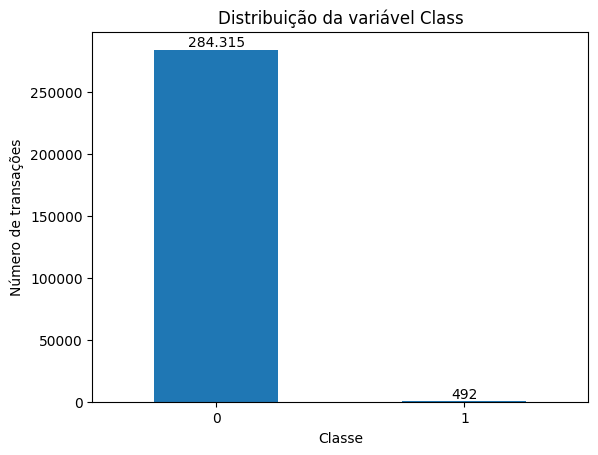

In [ ]:
# 4.1 Distribuição da variável-alvo

def formatar_inteiro(valor):
    return f"{int(valor):,}".replace(",", ".")

def formatar_decimal(valor, casas=2):
    texto = f"{float(valor):,.{casas}f}"
    return texto.replace(",", "#").replace(".", ",").replace("#", ".")

contagem = df["Class"].value_counts(dropna=False).sort_index()
percentual = (
    df["Class"]
    .value_counts(normalize=True, dropna=False)
    .sort_index()
    .mul(100)
)

distribuicao = pd.DataFrame({
    "Quantidade": contagem.map(formatar_inteiro),
    "Percentual": percentual.map(lambda x: f"{formatar_decimal(x, 4)}%"),
})

display(distribuicao)

classe_majoritaria = contagem.idxmax()
classe_minoritaria = contagem.idxmin()
razao_classes = contagem.max() / contagem.min()

print(
    f"Classe majoritária: {classe_majoritaria} "
    f"({formatar_inteiro(contagem.max())} registros)"
)
print(
    f"Classe minoritária: {classe_minoritaria} "
    f"({formatar_inteiro(contagem.min())} registros)"
)
print(f"Razão majoritária/minoritária: {formatar_decimal(razao_classes, 2)}:1")

ax = contagem.plot(
    kind="bar",
    title="Distribuição da variável Class",
    rot=0
)
ax.set_xlabel("Classe")
ax.set_ylabel("Número de transações")

for posicao, valor in enumerate(contagem.values):
    ax.text(
        posicao,
        valor,
        formatar_inteiro(valor),
        ha="center",
        va="bottom"
    )

plt.show()


## 5. Estatística descritiva e análise exploratória

Depois de validar a estrutura, a qualidade inicial e o desbalanceamento da variável-alvo, o próximo passo é caracterizar numericamente as variáveis e observar padrões visuais antes de qualquer transformação ou modelagem.

A apresentação prioriza **leitura humana**: `Amount` é exibido com duas casas decimais, `Time` é convertido de segundos para horas nas tabelas e gráficos desta etapa e contagens são apresentadas como inteiros. Essas escolhas não alteram os dados originais.

**Referências do Módulo 05**
- **5.3 — Bibliotecas Essenciais de Python para Análise de Dados:** estatística descritiva e exploração com Pandas.
- **5.6 — Visualização Avançada de Dados com Python:** uso de gráficos para investigar distribuições e comunicar padrões.
- **5.8 — Detecção de Anomalias em Transações em Python:** análise de `Amount`, `Time` e diferenças entre transações normais e fraudulentas.

**Critério desta etapa:** descrever e visualizar o que os dados mostram. Nenhuma transformação, exclusão de observações ou decisão de modelagem será realizada aqui. Diferenças de distribuição e associações observadas não devem ser interpretadas como causalidade.


### 5.1 Estatística descritiva direcionada

O resumo numérico será concentrado nas variáveis diretamente interpretáveis do dataset, evitando uma tabela extensa com estatísticas de utilidade desigual.

- **`Amount`:** média, mediana, dispersão, quartis, mínimo e máximo, apresentados com duas casas decimais. O campo representa o valor da transação, mas a fonte disponível não informa a moeda.
- **`Time`:** a coluna original permanece em segundos, mas a apresentação desta etapa converte os pontos da distribuição para **horas decorridas desde a primeira transação**.
- **`Class`:** não será resumida novamente aqui, pois sua distribuição já foi analisada na seção 4.
- **`V1` a `V28`:** são componentes PCA anonimizados, sem significado de negócio individual divulgado; por isso não serão exibidos em uma tabela descritiva extensa nesta etapa.

Também será feita uma verificação específica dos registros com **`Amount = 0`**. O valor zero será tratado como ocorrência a investigar, não como erro ou transação inválida por definição, pois a fonte disponível não informa o significado operacional desses casos.


In [ ]:
# 5.1 Estatística descritiva direcionada

def formatar_inteiro(valor):
    return f"{int(valor):,}".replace(",", ".")

def formatar_decimal(valor, casas=2):
    texto = f"{float(valor):,.{casas}f}"
    return texto.replace(",", "#").replace(".", ",").replace("#", ".")

# Resumo de Amount — valores exibidos com duas casas decimais
resumo_amount = pd.DataFrame({
    "Métrica": [
        "Registros",
        "Média",
        "Mediana",
        "Desvio-padrão",
        "1º quartil (25%)",
        "3º quartil (75%)",
        "Mínimo",
        "Máximo",
    ],
    "Resultado": [
        formatar_inteiro(df["Amount"].count()),
        formatar_decimal(df["Amount"].mean(), 2),
        formatar_decimal(df["Amount"].median(), 2),
        formatar_decimal(df["Amount"].std(), 2),
        formatar_decimal(df["Amount"].quantile(0.25), 2),
        formatar_decimal(df["Amount"].quantile(0.75), 2),
        formatar_decimal(df["Amount"].min(), 2),
        formatar_decimal(df["Amount"].max(), 2),
    ],
})

print("Resumo de Amount — valor da transação (moeda não informada)")
display(resumo_amount)

# Resumo de Time — convertido para horas apenas para apresentação
time_horas = df["Time"] / 3600
resumo_time = pd.DataFrame({
    "Métrica": [
        "Início",
        "1º quartil (25%)",
        "Mediana",
        "3º quartil (75%)",
        "Fim",
        "Amplitude total",
    ],
    "Resultado": [
        f"{formatar_decimal(time_horas.min(), 2)} h",
        f"{formatar_decimal(time_horas.quantile(0.25), 2)} h",
        f"{formatar_decimal(time_horas.median(), 2)} h",
        f"{formatar_decimal(time_horas.quantile(0.75), 2)} h",
        f"{formatar_decimal(time_horas.max(), 2)} h",
        f"{formatar_decimal(time_horas.max() - time_horas.min(), 2)} h",
    ],
})

print("Resumo de Time — horas decorridas desde a primeira transação")
display(resumo_time)

# Diagnóstico específico de Amount = 0 — sem remoção automática
mask_amount_zero = df["Amount"].eq(0)
amount_zero_total = int(mask_amount_zero.sum())
amount_zero_pct = (amount_zero_total / len(df)) * 100

amount_zero_por_classe = (
    df.loc[mask_amount_zero, "Class"]
      .value_counts()
      .reindex([0, 1], fill_value=0)
      .astype(int)
)

fraudes_totais = int((df["Class"] == 1).sum())
fraudes_amount_zero = int(amount_zero_por_classe.loc[1])
fraudes_amount_zero_pct = (
    (fraudes_amount_zero / fraudes_totais) * 100
    if fraudes_totais else 0.0
)
taxa_fraude_amount_zero = (
    (fraudes_amount_zero / amount_zero_total) * 100
    if amount_zero_total else 0.0
)

resumo_amount_zero = pd.DataFrame({
    "Métrica": [
        "Registros com Amount = 0",
        "% do dataset",
        "Classe 0 com Amount = 0",
        "Classe 1 com Amount = 0",
        "% das fraudes com Amount = 0",
        "% dos Amount = 0 que são fraude",
    ],
    "Resultado": [
        formatar_inteiro(amount_zero_total),
        f"{formatar_decimal(amount_zero_pct, 4)}%",
        formatar_inteiro(amount_zero_por_classe.loc[0]),
        formatar_inteiro(fraudes_amount_zero),
        f"{formatar_decimal(fraudes_amount_zero_pct, 4)}%",
        f"{formatar_decimal(taxa_fraude_amount_zero, 4)}%",
    ],
})

print("Diagnóstico de Amount = 0")
display(resumo_amount_zero)

print(f"Componentes PCA disponíveis: {variaveis_v[0]} a {variaveis_v[-1]} ({len(variaveis_v)} componentes).")
print("Nenhum registro é removido nesta etapa.")


Resumo de Amount — valor da transação (moeda não informada)


,Métrica,Resultado
0,Registros,284.807
1,Média,"88,35"
2,Mediana,"22,00"
3,Desvio-padrão,"250,12"
4,1º quartil (25%),"5,60"
5,3º quartil (75%),"77,16"
6,Mínimo,"0,00"
7,Máximo,"25.691,16"


Resumo de Time — horas decorridas desde a primeira transação


,Métrica,Resultado
0,Início,"0,00 h"
1,1º quartil (25%),"15,06 h"
2,Mediana,"23,53 h"
3,3º quartil (75%),"38,70 h"
4,Fim,"48,00 h"
5,Amplitude total,"48,00 h"


Diagnóstico de Amount = 0


,Métrica,Resultado
0,Registros com Amount = 0,1.825
1,% do dataset,"0,6408%"
2,Classe 0 com Amount = 0,1.798
3,Classe 1 com Amount = 0,27
4,% das fraudes com Amount = 0,"5,4878%"
5,% dos Amount = 0 que são fraude,"1,4795%"


Componentes PCA disponíveis: V1 a V28 (28 componentes).
Nenhum registro é removido nesta etapa.


### 5.2 Visualizações exploratórias

As visualizações complementam o resumo numérico e procuram responder três perguntas iniciais:

- `Amount` apresenta concentração em valores baixos e cauda de valores elevados?
- o perfil de `Amount` difere visualmente entre as classes `0` e `1`?
- como o volume de transações se distribui ao longo das aproximadamente 48 horas observadas?

**Como ler os histogramas:** cada variável é dividida em 50 intervalos (`bins`). A altura de cada barra representa o **número de transações** cujos valores caem naquele intervalo. O eixo Y, portanto, mostra contagens; o eixo X mostra faixas de valor (`Amount`) ou de tempo em horas (`Time`).

As escalas do eixo Y podem ser muito diferentes entre os gráficos porque a concentração dos dados também é diferente. O boxplot pode ficar visualmente comprimido pela presença de valores extremos; isso é informação sobre a dispersão, não necessariamente um erro do gráfico.


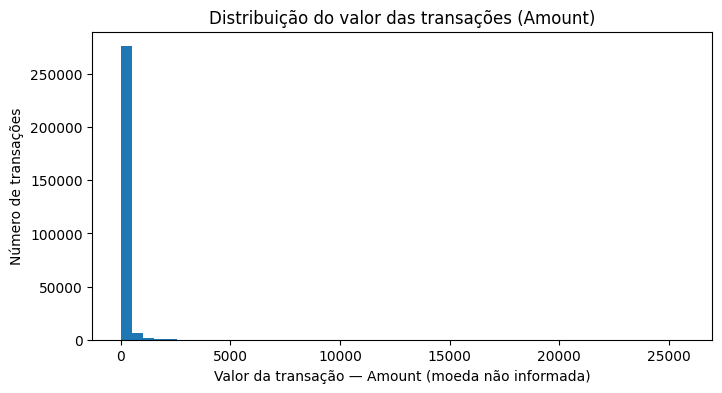

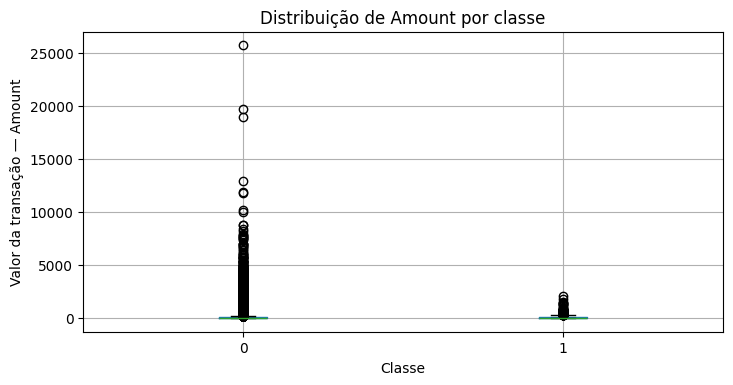

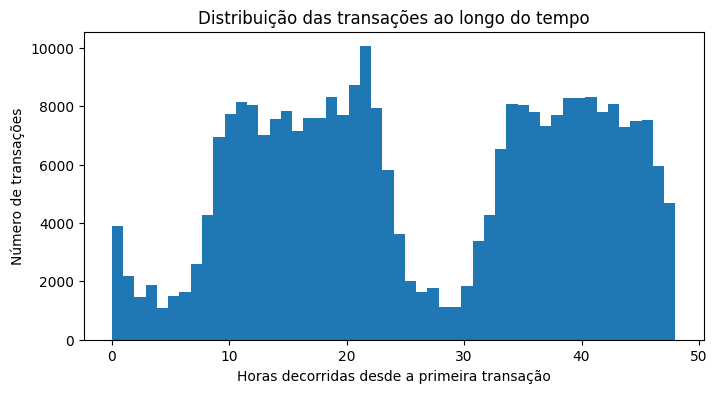

In [ ]:
# 5.2 Visualizações exploratórias

if "Amount" in df.columns:
    df["Amount"].plot(
        kind="hist",
        bins=50,
        title="Distribuição do valor das transações (Amount)",
        figsize=(8, 4)
    )
    plt.xlabel("Valor da transação — Amount (moeda não informada)")
    plt.ylabel("Número de transações")
    plt.show()

    df.boxplot(
        column="Amount",
        by="Class",
        figsize=(8, 4)
    )
    plt.title("Distribuição de Amount por classe")
    plt.xlabel("Classe")
    plt.ylabel("Valor da transação — Amount")
    plt.suptitle("")
    plt.show()

if "Time" in df.columns:
    time_horas = df["Time"] / 3600
    time_horas.plot(
        kind="hist",
        bins=50,
        title="Distribuição das transações ao longo do tempo",
        figsize=(8, 4)
    )
    plt.xlabel("Horas decorridas desde a primeira transação")
    plt.ylabel("Número de transações")
    plt.show()


## 6. Aprofundamento exploratório

Depois da distribuição da variável-alvo e da exploração inicial de `Amount` e `Time`, esta etapa compara diretamente as classes e procura associações que possam orientar a preparação e a modelagem.

O objetivo não é provar causalidade nem escolher um modelo, mas responder perguntas mais específicas:

- `Amount` apresenta comportamento diferente entre transações normais e fraudulentas?
- existem intervalos da janela temporal com proporção de fraude relativamente maior?
- quais variáveis numéricas apresentam maior associação linear com `Class`?

**Referências do Módulo 05**
- **5.3 — Bibliotecas Essenciais de Python para Análise de Dados:** agrupamentos, estatística e exploração com Pandas.
- **5.6 — Visualização Avançada de Dados com Python:** comparação visual de padrões.
- **5.7 — Boas Práticas, Testes e Otimização de Código em Python:** leitura crítica de métricas e resultados.
- **5.8 — Detecção de Anomalias em Transações em Python:** investigação de padrões entre `Amount`, `Time`, componentes `V` e a classe de fraude.

**Critério desta etapa:** associações observadas servem como evidência exploratória. Nenhuma variável será removida, transformada ou declarada causal com base apenas nestas análises.


### 6.1 `Amount` por classe

Esta análise compara a distribuição de `Amount` entre `Class = 0` e `Class = 1`.

Serão observados:

- quantidade de registros;
- média e mediana;
- dispersão;
- mínimo e máximo;
- quantis de 25%, 75%, 90%, 95% e 99%.

Os valores continuam sendo apresentados com duas casas decimais e sem símbolo monetário, porque a fonte não informa a moeda.


In [ ]:
# 6.1 `Amount` por classe

def formatar_inteiro(valor):
    return f"{int(valor):,}".replace(",", ".")

def formatar_decimal(valor, casas=2):
    texto = f"{float(valor):,.{casas}f}"
    return texto.replace(",", "#").replace(".", ",").replace("#", ".")

resumo_amount_classe = (
    df.groupby("Class")["Amount"]
      .agg(
          Registros="count",
          Média="mean",
          Mediana="median",
          Desvio_padrão="std",
          Mínimo="min",
          Máximo="max",
      )
)

quantis_amount_classe = (
    df.groupby("Class")["Amount"]
      .quantile([0.25, 0.75, 0.90, 0.95, 0.99])
      .unstack()
      .rename(columns={
          0.25: "Q25",
          0.75: "Q75",
          0.90: "Q90",
          0.95: "Q95",
          0.99: "Q99",
      })
)

resumo_amount_classe = resumo_amount_classe.join(quantis_amount_classe)

resumo_amount_formatado = resumo_amount_classe.copy()
resumo_amount_formatado["Registros"] = resumo_amount_formatado["Registros"].map(formatar_inteiro)

for coluna in resumo_amount_formatado.columns.drop("Registros"):
    resumo_amount_formatado[coluna] = resumo_amount_formatado[coluna].map(
        lambda x: formatar_decimal(x, 2)
    )

display(resumo_amount_formatado)


,Registros,Média,Mediana,Desvio_padrão,Mínimo,Máximo,Q25,Q75,Q90,Q95,Q99
Class,,,,,,,,,,,
0,284.315,"88,29","22,00","250,11","0,00","25.691,16","5,65","77,05","202,72","364,41","1.016,97"
1,492,"122,21","9,25","256,68","0,00","2.125,87","1,00","105,89","346,75","640,90","1.357,43"


### 6.2 Comportamento temporal por classe

A coluna `Time` permanece armazenada em segundos, mas será convertida para **horas apenas para análise e apresentação**.

A janela de aproximadamente 48 horas será dividida em intervalos de **2 horas**. Para cada intervalo serão calculados:

- número total de transações;
- número de fraudes;
- percentual de fraudes dentro daquele intervalo.

A métrica principal será a **taxa de fraude do intervalo**, e não apenas a contagem de fraudes, porque o volume total de transações varia ao longo do tempo.


,Intervalo,Transações,Fraudes,Taxa_fraude_pct
0,00–02 h,6.180,4,"0,0647%"
1,02–04 h,3.397,34,"1,0009%"
2,04–06 h,2.763,17,"0,6153%"
3,06–08 h,5.199,26,"0,5001%"
4,08–10 h,13.057,20,"0,1532%"
5,10–12 h,16.805,45,"0,2678%"
6,12–14 h,15.317,18,"0,1175%"
7,14–16 h,15.865,27,"0,1702%"
8,16–18 h,15.668,26,"0,1659%"
9,18–20 h,16.601,22,"0,1325%"


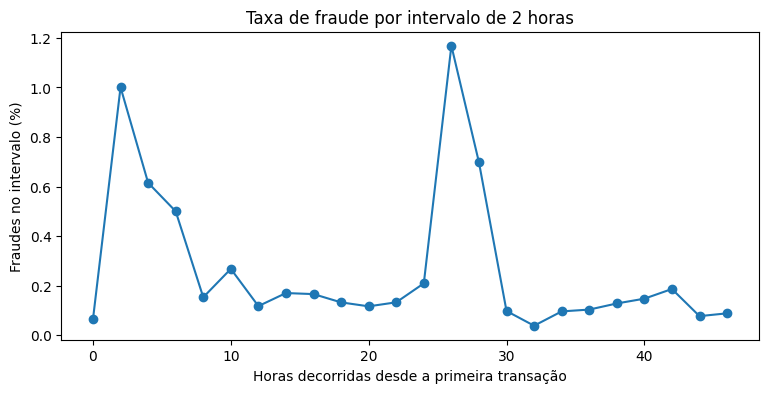

In [ ]:
# 6.2 Comportamento temporal por classe

df_temporal = df[["Time", "Class"]].copy()
df_temporal["Hora"] = df_temporal["Time"] / 3600
df_temporal["Inicio_intervalo_h"] = (
    np.floor(df_temporal["Hora"] / 2) * 2
).astype(int)

temporal = (
    df_temporal.groupby("Inicio_intervalo_h")
    .agg(
        Transações=("Class", "size"),
        Fraudes=("Class", "sum"),
    )
    .reset_index()
)

temporal["Taxa_fraude_pct"] = (
    temporal["Fraudes"] / temporal["Transações"] * 100
)

temporal["Intervalo"] = temporal["Inicio_intervalo_h"].map(
    lambda h: f"{h:02d}–{h + 2:02d} h"
)

temporal_exibicao = temporal[[
    "Intervalo",
    "Transações",
    "Fraudes",
    "Taxa_fraude_pct",
]].copy()

temporal_exibicao["Transações"] = temporal_exibicao["Transações"].map(
    lambda x: f"{int(x):,}".replace(",", ".")
)
temporal_exibicao["Fraudes"] = temporal_exibicao["Fraudes"].map(
    lambda x: f"{int(x):,}".replace(",", ".")
)
temporal_exibicao["Taxa_fraude_pct"] = temporal_exibicao["Taxa_fraude_pct"].map(
    lambda x: f"{x:.4f}%".replace(".", ",")
)

display(temporal_exibicao)

ax = temporal.plot(
    x="Inicio_intervalo_h",
    y="Taxa_fraude_pct",
    kind="line",
    marker="o",
    figsize=(9, 4),
    legend=False,
    title="Taxa de fraude por intervalo de 2 horas",
)

ax.set_xlabel("Horas decorridas desde a primeira transação")
ax.set_ylabel("Fraudes no intervalo (%)")
plt.show()


### 6.3 Relações numéricas com `Class`

Nesta etapa é calculada a correlação de cada variável numérica com `Class`.

Como `Class` é codificada como `0` e `1`, essa correlação funciona como uma **triagem de associação linear** entre cada variável e a ocorrência de fraude.

**Como interpretar o resultado:**

- o **sinal** indica a direção da associação;
- correlação **negativa** significa que valores mais baixos da variável tendem a aparecer relativamente mais associados à classe `1`;
- correlação **positiva** significa que valores mais altos tendem a aparecer relativamente mais associados à classe `1`;
- a **magnitude absoluta** indica a força da associação linear: quanto mais distante de zero, maior a associação linear observada;
- o ranking é feito pelo valor absoluto para não tratar uma correlação negativa forte como menos importante que uma positiva.

Exemplo: `V17 = -0,3265` não significa que `V17` “cause” fraude nem que valores negativos sejam fraudes por definição. Significa apenas que, neste dataset, há uma associação linear relevante entre valores relativamente menores de `V17` e `Class = 1`.

A leitura exige cautela:

- correlação não implica causalidade;
- correlação baixa não significa ausência de valor preditivo;
- relações não lineares e interações entre variáveis podem não aparecer bem nesta medida;
- `V1` a `V28` são componentes PCA anonimizados, portanto uma associação forte não revela diretamente o significado de negócio da variável original;
- importância de modelo e SHAP, analisados posteriormente, podem produzir uma hierarquia diferente porque medem relações mais complexas do que correlação simples.

**Escolha visual:** o gráfico de barras horizontais é usado aqui porque permite comparar simultaneamente direção e magnitude das correlações.


,Correlação,Correlação_absoluta
V17,"-0,3265","0,3265"
V14,"-0,3025","0,3025"
V12,"-0,2606","0,2606"
V10,"-0,2169","0,2169"
V16,"-0,1965","0,1965"
V3,"-0,1930","0,1930"
V7,"-0,1873","0,1873"
V11,"0,1549","0,1549"
V4,"0,1334","0,1334"
V18,"-0,1115","0,1115"


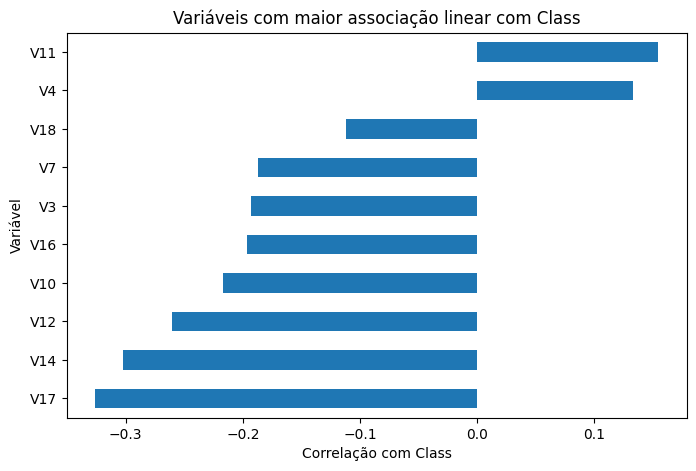

In [ ]:
# 6.3 Relações numéricas com `Class`

correlacoes = (
    df.select_dtypes(include=np.number)
      .corr()["Class"]
      .drop("Class")
)

ordem = correlacoes.abs().sort_values(ascending=False)

top_correlacoes = pd.DataFrame({
    "Correlação": correlacoes.loc[ordem.head(10).index],
    "Correlação_absoluta": ordem.head(10),
})

top_correlacoes_exibicao = top_correlacoes.copy()
top_correlacoes_exibicao["Correlação"] = top_correlacoes_exibicao["Correlação"].map(
    lambda x: f"{x:.4f}".replace(".", ",")
)
top_correlacoes_exibicao["Correlação_absoluta"] = top_correlacoes_exibicao["Correlação_absoluta"].map(
    lambda x: f"{x:.4f}".replace(".", ",")
)

display(top_correlacoes_exibicao)

ax = (
    top_correlacoes["Correlação"]
    .sort_values()
    .plot(
        kind="barh",
        figsize=(8, 5),
        title="Variáveis com maior associação linear com Class",
    )
)

ax.set_xlabel("Correlação com Class")
ax.set_ylabel("Variável")
plt.show()


### Checkpoint 2 — Desbalanceamento e análise exploratória

**Referência cumulativa:** o **Checkpoint 1** permanece como baseline de estrutura, qualidade e duplicatas. Este checkpoint registra apenas as evidências acrescentadas pelas seções 4–6.

- **Desbalanceamento:** `Class 0 = 99,8273%` e `Class 1 = 0,1727%`, razão aproximada de **577,88:1**. Acurácia isolada não é métrica suficiente para o problema.
- **`Amount`:** distribuição fortemente assimétrica. Fraudes não podem ser resumidas como “valores mais altos”: a mediana da classe 1 é menor (**9,25** vs **22,00**), enquanto seus quantis superiores são maiores (ex.: Q95 **640,90** vs **364,41**).
- **`Amount = 0`:** existem **1.825** registros; **27** são fraudes. Isso corresponde a **5,4878% de todas as fraudes** e a uma taxa de fraude de **1,4795%** dentro do grupo `Amount = 0`, aproximadamente **8,56×** a taxa global (**0,1727%**). É um sinal exploratório, não uma regra causal; nenhum registro é removido por esse motivo.
- **Tempo:** há recorrência relativa em pares equivalentes separados por 24 horas — **02–04 h ↔ 26–28 h** e **04–06 h ↔ 28–30 h** — mas o padrão não se repete integralmente em **06–08 h ↔ 30–32 h**. A amostra de ~48 h sugere um padrão a investigar, não uma regra horária geral.
- **Associação linear:** `V17 (-0,3265)`, `V14 (-0,3025)` e `V12 (-0,2606)` apresentaram as maiores correlações absolutas com `Class`. O sinal indica direção; a magnitude indica força linear. Correlação não equivale a causalidade nem a importância final do modelo.
- **Visualização:** o gráfico horizontal do 6.3 é mantido por mostrar de forma direta sinal e magnitude das associações. Curvas **ROC** e **Precision-Recall**, dependentes de probabilidades de modelo, pertencem à seção 13.

**Conclusão do bloco:** o conjunto apresenta desbalanceamento severo e sinais exploratórios em `Amount`, tempo e componentes PCA. Esses achados justificam avançar para preparação e modelagem, mas nenhum deles isoladamente constitui regra de fraude.


## 7. Feature engineering de `Amount`

A análise exploratória mostrou que `Amount` possui forte assimetria à direita: a mediana é **22,00**, a média **88,35** e o valor máximo **25.691,16**. Também foram identificados registros com `Amount = 0`.

Essas evidências justificam testar a transformação `log(1 + x)`, apresentada no 5.8, porque ela:

- comprime valores elevados sem eliminar a ordenação dos dados;
- reduz a influência visual e numérica da cauda longa;
- permanece definida para `Amount = 0`, pois `log(1 + 0) = 0`;
- cria uma nova representação da variável sem destruir o valor original.

**Referências do Módulo 05**
- **5.4 — Processamento e Limpeza de Dados:** transformação de variáveis e preparação dos dados.
- **5.8 — Detecção de Anomalias em Transações:** aplicação de transformação logarítmica em `Amount` como feature engineering.

**Critério desta etapa:** criar `Amount_log` e avaliar o efeito da transformação. `Amount` original será preservado. A escolha de qual representação entrará no modelo será feita posteriormente, na definição de `X`.


### 7.1 Transformação logarítmica e comparação

A transformação será aplicada com `numpy.log1p()`, equivalente a `log(1 + x)`.

Antes da transformação, o código confirma que `Amount` existe e que não há valores negativos. Depois serão comparados:

- mínimo;
- mediana;
- 3º quartil;
- máximo;
- assimetria (`skewness`).

A assimetria mede quanto a distribuição se afasta de uma forma aproximadamente simétrica. Valores positivos elevados indicam uma cauda longa à direita. O objetivo não é obrigatoriamente obter assimetria zero, mas verificar se `Amount_log` reduz de forma material a concentração extrema observada em `Amount`.


,Métrica,Amount,Amount_log
0,Mínimo,"0,00","0,00"
1,Mediana,"22,00","3,14"
2,3º quartil (75%),"77,16","4,36"
3,Máximo,"25.691,16","10,15"
4,Assimetria,"16,9777","0,1627"


Registros com Amount = 0 preservados após log1p: 1.825


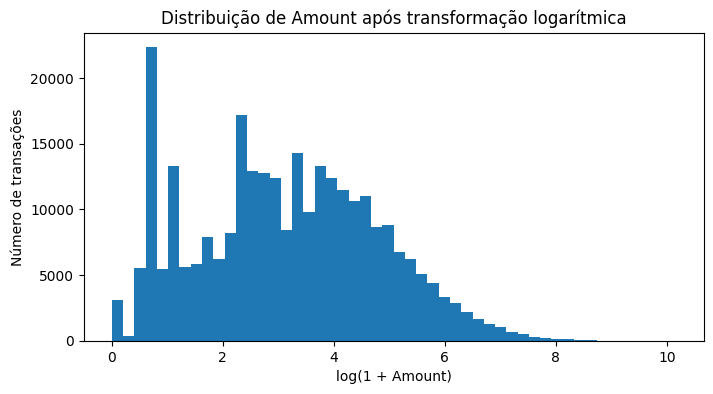

In [ ]:
# 7.1 Transformação logarítmica e comparação

if "Amount" not in df.columns:
    raise KeyError("A coluna 'Amount' não está disponível no dataset.")

if (df["Amount"] < 0).any():
    raise ValueError(
        "Foram encontrados valores negativos em Amount. "
        "A transformação log1p deve ser reavaliada antes de continuar."
    )

# Cópia de trabalho: o dataframe original permanece preservado.
df_model = df.copy()
df_model["Amount_log"] = np.log1p(df_model["Amount"])

def formatar_decimal(valor, casas=2):
    texto = f"{float(valor):,.{casas}f}"
    return texto.replace(",", "#").replace(".", ",").replace("#", ".")

resumo_transformacao = pd.DataFrame({
    "Métrica": [
        "Mínimo",
        "Mediana",
        "3º quartil (75%)",
        "Máximo",
        "Assimetria",
    ],
    "Amount": [
        formatar_decimal(df_model["Amount"].min(), 2),
        formatar_decimal(df_model["Amount"].median(), 2),
        formatar_decimal(df_model["Amount"].quantile(0.75), 2),
        formatar_decimal(df_model["Amount"].max(), 2),
        formatar_decimal(df_model["Amount"].skew(), 4),
    ],
    "Amount_log": [
        formatar_decimal(df_model["Amount_log"].min(), 2),
        formatar_decimal(df_model["Amount_log"].median(), 2),
        formatar_decimal(df_model["Amount_log"].quantile(0.75), 2),
        formatar_decimal(df_model["Amount_log"].max(), 2),
        formatar_decimal(df_model["Amount_log"].skew(), 4),
    ],
})

display(resumo_transformacao)

amount_zero_preservados = int(
    ((df_model["Amount"] == 0) & (df_model["Amount_log"] == 0)).sum()
)

print(
    "Registros com Amount = 0 preservados após log1p: "
    f"{amount_zero_preservados:,}".replace(",", ".")
)

df_model["Amount_log"].plot(
    kind="hist",
    bins=50,
    figsize=(8, 4),
    title="Distribuição de Amount após transformação logarítmica",
)
plt.xlabel("log(1 + Amount)")
plt.ylabel("Número de transações")
plt.show()


**Síntese pós-execução:** `log1p` reduziu a assimetria de `Amount` de **16,9777** para **0,1627**, preservando os **1.825 registros com `Amount = 0`**. A transformação comprimiu a cauda longa sem remover observações e passou a sustentar o uso de `Amount_log` na modelagem.


## 8. Definição das variáveis de entrada (`X`) e alvo (`y`)

A transformação da seção 7 reduziu fortemente a assimetria de `Amount`, tornando `Amount_log` uma representação mais adequada para a etapa de modelagem.

Nesta versão do fluxo será adotada a seguinte decisão:

- **`y`**: `Class`, variável-alvo;
- **`X`**: `Time`, `V1`–`V28` e `Amount_log`;
- **`Amount` original**: preservado em `df_model`, mas excluído de `X` para evitar levar ao modelo duas representações diretamente derivadas do mesmo valor.

`Time` será mantido porque a análise exploratória identificou variação temporal na taxa de fraude. O dado continua em segundos no dataframe; sua escala será tratada posteriormente.

### Referências ao Módulo 05

- **5.4 — Processamento e Limpeza de Dados:** preparação das variáveis que serão utilizadas pelo modelo;
- **5.8 — Detecção de Anomalias em Transações:** separação entre *features* (`X`) e variável-alvo (`y`) como etapa de preparação para treinamento.

**Critério desta etapa:** definir explicitamente as variáveis que entram no treinamento, sem ainda alterar sua escala.


### 8.1 Definição de X e y

A célula organiza o dataset em dois objetos distintos:

- `X`, contendo apenas as variáveis que poderão ser usadas para explicar ou prever a classe;
- `y`, contendo exclusivamente `Class`, que representa o resultado que o modelo deverá aprender a classificar.

A exclusão de `Amount` original é deliberada: `Amount_log` será usado como sua representação transformada, enquanto o valor bruto continua preservado em `df_model` para rastreabilidade e análises posteriores.


In [ ]:
# 8.1 Definição de X e y

TARGET = "Class"
COLUNAS_EXCLUIR = [TARGET, "Amount"]

y = df_model[TARGET].copy()
X = df_model.drop(columns=COLUNAS_EXCLUIR).copy()

resumo_xy = pd.DataFrame({
    "Conjunto": ["X — features", "y — alvo"],
    "Linhas": [len(X), len(y)],
    "Colunas": [X.shape[1], 1],
})

display(resumo_xy)

print("Features utilizadas:")
print(X.columns.tolist())

print("\nFeatures excluídas do treinamento:")
print(COLUNAS_EXCLUIR)


,Conjunto,Linhas,Colunas
0,X — features,284807,30
1,y — alvo,284807,1


Features utilizadas:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log']

Features excluídas do treinamento:
['Class', 'Amount']


**Síntese pós-execução:** `X` foi definido com **284.807 linhas e 30 features** (`Time`, `V1`–`V28` e `Amount_log`), enquanto `y` contém as mesmas **284.807 linhas** e apenas `Class`. A separação confirma que nenhuma observação foi perdida nesta etapa.


## 9. Divisão treino/teste com estratificação

O conjunto será dividido em **70% para treino e 30% para teste**, seguindo a proporção apresentada no 5.8.

Como `Class = 1` representa apenas cerca de 0,17% da base, a divisão utilizará `stratify=y` para preservar aproximadamente a mesma proporção de fraudes nos dois subconjuntos.

O conjunto de teste será mantido separado para avaliação posterior e não participará do ajuste de transformações ou técnicas de balanceamento.

### Referências ao Módulo 05

- **5.8 — Detecção de Anomalias em Transações:** uso de `train_test_split`, divisão 70/30, `random_state=42` para reprodutibilidade e `stratify=y` para preservar a proporção da classe rara.

**Critério desta etapa:** confirmar que treino e teste preservam o desbalanceamento original e que o conjunto de teste continua representativo do problema real.


### 9.1 Split estratificado

A divisão será validada comparando, na base total, no treino e no teste:

- quantidade total de registros;
- quantidade de transações normais;
- quantidade de fraudes;
- percentual de fraude.

O objetivo é verificar empiricamente se a estratificação manteve a classe minoritária representada de forma proporcional nos dois subconjuntos.


In [ ]:
# 9.1 Split estratificado

TEST_SIZE = 0.30

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

def resumo_particao(nome, alvo):
    total = len(alvo)
    fraudes = int((alvo == 1).sum())
    normais = int((alvo == 0).sum())

    return {
        "Conjunto": nome,
        "Registros": total,
        "Classe 0": normais,
        "Classe 1": fraudes,
        "Fraude (%)": (fraudes / total) * 100,
    }

resumo_split = pd.DataFrame([
    resumo_particao("Base total", y),
    resumo_particao("Treino", y_train),
    resumo_particao("Teste", y_test),
])

resumo_split_exibicao = resumo_split.copy()

for coluna in ["Registros", "Classe 0", "Classe 1"]:
    resumo_split_exibicao[coluna] = resumo_split_exibicao[coluna].map(
        lambda x: f"{int(x):,}".replace(",", ".")
    )

resumo_split_exibicao["Fraude (%)"] = resumo_split_exibicao["Fraude (%)"].map(
    lambda x: f"{x:.4f}%".replace(".", ",")
)

display(resumo_split_exibicao)


,Conjunto,Registros,Classe 0,Classe 1,Fraude (%)
0,Base total,284.807,284.315,492,"0,1727%"
1,Treino,199.364,199.020,344,"0,1725%"
2,Teste,85.443,85.295,148,"0,1732%"


**Síntese pós-execução:** a divisão gerou **199.364 registros de treino** e **85.443 de teste**. A taxa de fraude permaneceu praticamente estável: **0,1725% no treino** e **0,1732% no teste**, frente a **0,1727% na base total**. A estratificação preservou adequadamente a classe rara.


## 10. Padronização sem vazamento de dados

Para a Regressão Logística, as features serão padronizadas com `StandardScaler`.

O ponto metodológico central é a ordem:

1. o scaler é **ajustado somente em `X_train`**;
2. os parâmetros aprendidos no treino são aplicados a `X_train` e `X_test`;
3. nenhuma informação estatística do teste participa do `fit`.

Isso evita **data leakage**: o conjunto de teste permanece uma amostra não utilizada para aprender médias, desvios ou qualquer parâmetro de preparação.

Todas as features de `X` serão padronizadas nesta etapa. Essa decisão é especialmente adequada ao baseline de Regressão Logística; modelos baseados em árvores são menos sensíveis à escala.

### Referências ao Módulo 05

- **5.4 — Processamento e Limpeza de Dados:** padronização como etapa de pré-processamento;
- **5.7 — Boas Práticas, Testes e Otimização de Código em Python:** separação consistente entre preparação, validação e avaliação;
- **5.8 — Detecção de Anomalias em Transações:** uso de `StandardScaler` antes da modelagem.

**Aprimoramento metodológico:** o 5.8 apresenta a padronização como parte da preparação. Neste notebook, o `fit` do scaler é realizado **somente após o split e apenas sobre o treino**, preservando a independência do conjunto de teste.

**Critério desta etapa:** produzir `X_train_scaled` e `X_test_scaled` preservando nomes, índices e separação entre treino e teste.


### 10.1 Padronização ajustada somente no treino

O scaler aprenderá média e desvio-padrão exclusivamente a partir de `X_train`. Em seguida, a mesma transformação será aplicada ao treino e ao teste.

A célula também verifica se, no conjunto de treino padronizado, as médias ficaram próximas de `0` e os desvios-padrão próximos de `1`. Essa checagem confirma o funcionamento da transformação sem utilizar o teste como fonte de aprendizado.


In [ ]:
# 10.1 Padronização ajustada somente no treino

COLUNAS_ESCALAR = X_train.columns.tolist()

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

verificacao_escala = pd.DataFrame({
    "Métrica": [
        "Maior média absoluta no treino",
        "Maior desvio absoluto de std=1 no treino",
    ],
    "Resultado": [
        X_train_scaled.mean().abs().max(),
        (X_train_scaled.std(ddof=0) - 1).abs().max(),
    ],
})

verificacao_escala["Resultado"] = verificacao_escala["Resultado"].map(
    lambda x: f"{x:.8f}".replace(".", ",")
)

display(verificacao_escala)

treino_linhas = f"{X_train_scaled.shape[0]:,}".replace(",", ".")
teste_linhas = f"{X_test_scaled.shape[0]:,}".replace(",", ".")

print(
    f"Treino preparado: {treino_linhas} linhas × "
    f"{X_train_scaled.shape[1]} features"
)
print(
    f"Teste preparado: {teste_linhas} linhas × "
    f"{X_test_scaled.shape[1]} features"
)


,Métrica,Resultado
0,Maior média absoluta no treino,"0,00000000"
1,Maior desvio absoluto de std=1 no treino,"0,00000000"


Treino preparado: 199.364 linhas × 30 features
Teste preparado: 85.443 linhas × 30 features


**Síntese pós-execução:** após o ajuste do `StandardScaler` exclusivamente em `X_train`, a maior média absoluta e o maior desvio em relação a `std = 1` foram exibidos como **0,00000000** no treino. Isso confirma a padronização esperada dentro da precisão mostrada, mantendo o teste fora do `fit`.


### Checkpoint 3 — Preparação dos dados e integridade do pipeline

**Referência cumulativa:** os Checkpoints 1 e 2 permanecem como baseline de qualidade, desbalanceamento e exploração. Este checkpoint registra apenas as decisões e evidências novas das seções 7–10.

- **Transformação de `Amount`:** `log1p` reduziu a assimetria de **16,9777** para **0,1627**, preservando os **1.825 registros com `Amount = 0`**. `Amount_log` foi adotado para modelagem e `Amount` bruto permaneceu preservado fora de `X`.
- **Features de modelagem:** `X` contém **30 variáveis** — `Time`, `V1`–`V28` e `Amount_log` — em **284.807 registros**; `y` contém `Class` para os mesmos registros.
- **Divisão estratificada:** treino com **199.364 registros** e teste com **85.443**. A taxa de fraude permaneceu estável: **0,1725% no treino**, **0,1732% no teste** e **0,1727% na base total**.
- **Integridade do teste:** o conjunto de teste permanece separado e não participa do aprendizado de parâmetros de preparação.
- **Padronização:** o `StandardScaler` foi ajustado exclusivamente em `X_train` e aplicado depois ao treino e ao teste. No treino padronizado, a maior média absoluta e o maior desvio em relação a `std = 1` foram **0,00000000** na precisão exibida.
- **Controle de leakage de pré-processamento:** nenhuma estatística de `X_test` participou do `fit` do scaler. A separação evita vazamento pelo escalonamento; o possível cruzamento de **registros duplicados idênticos** entre treino e teste permanece como verificação específica a ser auditada nos testes finais.

**Conclusão do bloco:** a entrada dos modelos está definida, estratificada e padronizada sem vazamento pelo processo de escalonamento. Neste ponto do fluxo, a auditoria específica de duplicatas idênticas ainda não havia sido executada; ela é concluída posteriormente nas seções 21 e 25 antes da deliberação final.


## 11. Baseline — Regressão Logística

Com os dados preparados no Checkpoint 3, iniciaremos a modelagem com **Regressão Logística**, utilizada no 5.8 como baseline de classificação.

O baseline serve como referência: modelos e estratégias posteriores só representam avanço quando melhoram métricas relevantes para fraude, e não apenas a acurácia global.

### Referências ao Módulo 05

- **5.7 — Boas Práticas, Testes e Otimização de Código em Python:** comparação por métricas e uso de uma referência consistente;
- **5.8 — Detecção de Anomalias em Transações:** Regressão Logística como baseline, `max_iter=1000`, treinamento, previsão e probabilidades da classe fraude.

**Critério desta etapa:** treinar o primeiro modelo sobre `X_train_scaled`, gerar previsões e probabilidades para o mesmo conjunto de teste preservado nas seções anteriores.


### 11.1 Treinamento do baseline

A configuração mantém `max_iter=1000`, conforme o fluxo apresentado no 5.8. Como as features já foram padronizadas, esperamos reduzir o risco de interrupção por falta de convergência.

A célula registra quantas iterações foram utilizadas e se o treinamento terminou antes do limite configurado. As métricas de qualidade serão analisadas separadamente na seção 12.


In [ ]:
# 11.1 Treinamento do baseline

from sklearn.linear_model import LogisticRegression

MAX_ITER_BASELINE = 1000

modelo_baseline = LogisticRegression(
    max_iter=MAX_ITER_BASELINE,
    random_state=RANDOM_STATE,
)

modelo_baseline.fit(X_train_scaled, y_train)

y_pred_baseline = modelo_baseline.predict(X_test_scaled)
y_score_baseline = modelo_baseline.predict_proba(X_test_scaled)[:, 1]

iteracoes_usadas = int(modelo_baseline.n_iter_[0])

resumo_baseline = pd.DataFrame({
    "Métrica": [
        "Iterações utilizadas",
        "Limite configurado",
        "Convergiu antes do limite",
        "Previsões geradas no teste",
    ],
    "Resultado": [
        iteracoes_usadas,
        MAX_ITER_BASELINE,
        "Sim" if iteracoes_usadas < MAX_ITER_BASELINE else "Não",
        len(y_pred_baseline),
    ],
})

display(resumo_baseline)


,Métrica,Resultado
0,Iterações utilizadas,19
1,Limite configurado,1000
2,Convergiu antes do limite,Sim
3,Previsões geradas no teste,85443


**Síntese pós-execução:** o modelo utilizou **19 iterações** de um limite de 1.000 e convergiu antes do máximo configurado. A preparação anterior foi suficiente para evitar o problema de convergência observado como warning no exemplo docente.


## 12. Avaliação do baseline

Em um conjunto tão desbalanceado, a acurácia não pode ser interpretada isoladamente. A avaliação deve concentrar atenção na classe `1` (**fraude**), tratada neste notebook como a **classe positiva**.

### Guia de leitura das métricas

A partir desta seção, as tabelas e checkpoints usam a nomenclatura abaixo:

| Termo | Significado | Leitura neste projeto |
|---|---|---|
| **TP — True Positive** | Verdadeiro positivo | Fraude real corretamente classificada como fraude. |
| **TN — True Negative** | Verdadeiro negativo | Transação normal corretamente classificada como normal. |
| **FP — False Positive** | Falso positivo | Transação normal classificada como fraude — um **falso alerta**. |
| **FN — False Negative** | Falso negativo | Fraude real classificada como normal — uma **fraude não detectada**. |
| **Accuracy / Acurácia** | Proporção total de acertos | Pode parecer muito alta neste dataset porque quase todas as transações são normais; por isso não deve ser usada isoladamente. |
| **Precision** | `TP / (TP + FP)` | Entre os alertas de fraude emitidos pelo modelo, quantos realmente eram fraude. Precision alta significa poucos falsos alertas. |
| **Recall** | `TP / (TP + FN)` | Entre todas as fraudes reais, quantas o modelo conseguiu detectar. Recall alto significa poucas fraudes perdidas. |
| **F1-score** | Média harmônica entre Precision e Recall | Resume o equilíbrio entre as duas métricas. Só fica alto quando **precision e recall** são simultaneamente bons. Varia de `0` a `1`; quanto maior, melhor o equilíbrio. |
| **ROC-AUC** | Área sob a curva ROC | Mede a capacidade geral de ordenar/separar as classes ao longo de vários thresholds. `0,5` representa desempenho próximo ao aleatório e `1,0` separação perfeita. Não é “percentual de fraudes detectadas”. |
| **Average Precision (AP)** | Resumo da curva Precision-Recall | Resume o desempenho de precision e recall ao longo dos thresholds. É especialmente útil em classes raras como fraude; quanto maior, melhor. |
| **Threshold** | Limiar de decisão | Probabilidade mínima a partir da qual o modelo passa a classificar a transação como fraude. Alterá-lo muda o equilíbrio entre FP e FN. |
| **Support** | Quantidade real de exemplos de uma classe | No `classification_report`, informa quantas observações daquela classe existem no conjunto avaliado. |

**Exemplo de leitura:** `F1 = 0,7986` corresponde a um F1 de aproximadamente **79,86%**. Já `FP = 22` significa **22 transações normais sinalizadas incorretamente como fraude**, enquanto `FN = 35` significa **35 fraudes reais que o modelo deixou passar**.

### Referências ao Módulo 05

- **5.7 — Boas Práticas, Testes e Otimização de Código em Python:** avaliação por métricas adequadas e resultados comparáveis;
- **5.8 — Detecção de Anomalias em Transações:** `classification_report`, precision, recall, F1, ROC-AUC e atenção ao desbalanceamento.

**Critério desta etapa:** usar o mesmo conjunto de teste preservado e registrar métricas que permitam comparar o baseline com os experimentos seguintes.


### 12.1 Métricas e matriz de confusão

A tabela reúne acurácia, precision, recall, F1, ROC-AUC e Average Precision, além das quatro células da matriz de confusão.

Para este projeto, `recall` da classe fraude recebe atenção especial porque mede quantas fraudes reais foram detectadas. `Precision` mostra quantos alertas de fraude estavam corretos, e F1 resume o equilíbrio entre essas duas medidas.


,Modelo,Acurácia,Precision,Recall,F1,ROC_AUC,Average_Precision,TN,FP,FN,TP
0,Regressão Logística — baseline,"0,9992","0,8598","0,6216","0,7216","0,9566","0,7095",85.280,15,56,92


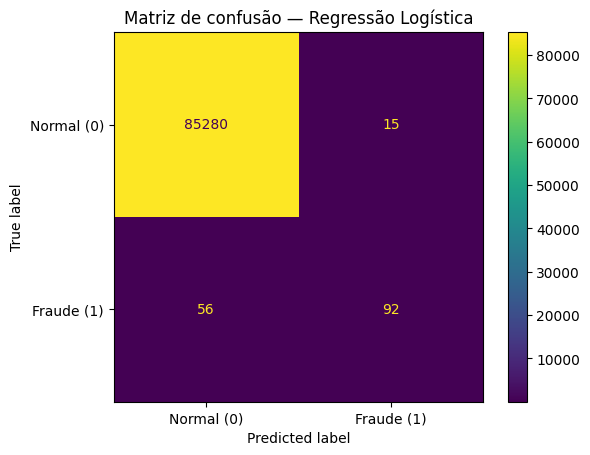

In [ ]:
# 12.1 Métricas e matriz de confusão

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay,
)

def calcular_metricas(nome, y_true, y_pred, y_score):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Modelo": nome,
        "Acurácia": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "Average_Precision": average_precision_score(y_true, y_score),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }

metricas_baseline = pd.DataFrame([
    calcular_metricas(
        "Regressão Logística — baseline",
        y_test,
        y_pred_baseline,
        y_score_baseline,
    )
])

metricas_baseline_exibicao = metricas_baseline.copy()

for coluna in ["Acurácia", "Precision", "Recall", "F1", "ROC_AUC", "Average_Precision"]:
    metricas_baseline_exibicao[coluna] = metricas_baseline_exibicao[coluna].map(
        lambda x: f"{x:.4f}".replace(".", ",")
    )

for coluna in ["TN", "FP", "FN", "TP"]:
    metricas_baseline_exibicao[coluna] = metricas_baseline_exibicao[coluna].map(
        lambda x: f"{int(x):,}".replace(",", ".")
    )

display(metricas_baseline_exibicao)

matriz_baseline = confusion_matrix(y_test, y_pred_baseline)
ConfusionMatrixDisplay(
    confusion_matrix=matriz_baseline,
    display_labels=["Normal (0)", "Fraude (1)"],
).plot()

plt.title("Matriz de confusão — Regressão Logística")
plt.show()


**Síntese pós-execução:** no teste preservado, o baseline obteve **precision 0,8598**, **recall 0,6216**, **F1 0,7216**, **ROC-AUC 0,9566** e **Average Precision 0,7095**. Foram detectadas **92 das 148 fraudes**, enquanto **56 fraudes passaram como normais**; ocorreram **15 falsos positivos**. A acurácia de **0,9992** permanece secundária diante do desbalanceamento.


## 13. Curvas ROC e Precision-Recall

As probabilidades produzidas pelo baseline permitem avaliar o comportamento do modelo em diferentes limiares de decisão, em vez de observar somente o threshold padrão de `0,5`.

### Referência ao Módulo 05

- **5.8 — Detecção de Anomalias em Transações:** curva ROC, AUC, curva Precision-Recall e trade-off entre detectar mais fraudes e aumentar falsos positivos.

A curva ROC compara **True Positive Rate** e **False Positive Rate**; a diagonal representa um classificador sem capacidade discriminativa. A curva Precision-Recall mostra diretamente o equilíbrio entre recall e precision e é particularmente informativa neste dataset, dado o forte desbalanceamento.

**Critério desta etapa:** avaliar capacidade de separação do baseline ao longo de diferentes thresholds sem escolher ainda um novo limiar operacional.


### 13.1 Curvas do baseline

Na ROC, melhor desempenho desloca a curva em direção ao canto superior esquerdo. Na Precision-Recall, interessa observar quanto de precision é preservado à medida que o recall aumenta.

A linha horizontal na curva Precision-Recall representa a prevalência de fraude no conjunto de teste e funciona como referência de base para o problema desbalanceado.


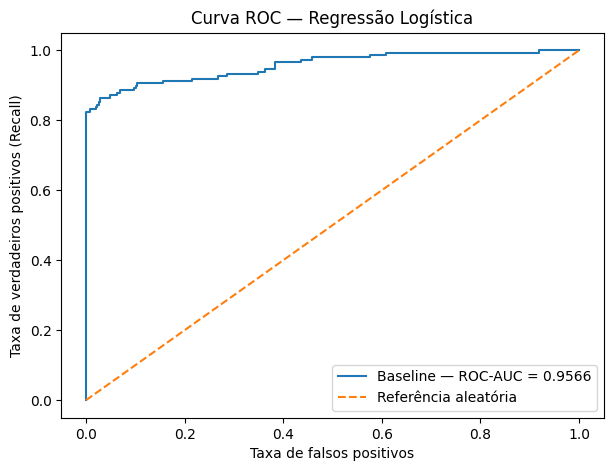

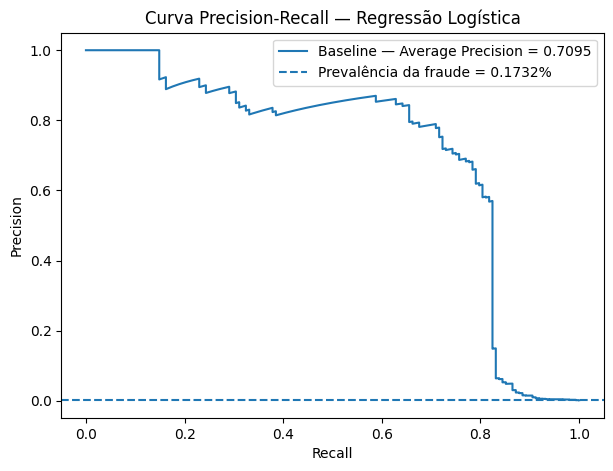

In [ ]:
# 13.1 Curvas ROC e Precision-Recall do baseline

fpr, tpr, _ = roc_curve(y_test, y_score_baseline)
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_score_baseline,
)

roc_auc_baseline = roc_auc_score(y_test, y_score_baseline)
ap_baseline = average_precision_score(y_test, y_score_baseline)
prevalencia_teste = float(y_test.mean())

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Baseline — ROC-AUC = {roc_auc_baseline:.4f}",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Referência aleatória",
)
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos (Recall)")
plt.title("Curva ROC — Regressão Logística")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(
    recall_curve,
    precision_curve,
    label=f"Baseline — Average Precision = {ap_baseline:.4f}",
)
plt.axhline(
    y=prevalencia_teste,
    linestyle="--",
    label=f"Prevalência da fraude = {prevalencia_teste:.4%}",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — Regressão Logística")
plt.legend()
plt.show()


**Síntese pós-execução:** o baseline apresentou **ROC-AUC 0,9566**, indicando boa capacidade geral de ordenação entre as classes, e **Average Precision 0,7095**, muito acima da prevalência de fraude no teste (~0,173%). A diferença entre essas métricas reforça que, neste problema, a curva Precision-Recall deve receber atenção especial.


## 14. Balanceamento do conjunto de treino

O 5.8 apresenta **undersampling** e **oversampling** como alternativas para enfrentar o desbalanceamento.

Neste primeiro experimento será usado **undersampling controlado**, porque permite observar de forma transparente o efeito de reduzir a classe majoritária sem criar exemplos sintéticos.

### Referência ao Módulo 05

- **5.8 — Detecção de Anomalias em Transações:** undersampling, oversampling e necessidade de comparar seus efeitos empiricamente.

**Regra de integridade:** o balanceamento será aplicado **somente ao treino**. O conjunto de teste original permanece intacto e continua sendo a referência comum para comparação.

**Critério desta etapa:** verificar se o ganho potencial de recall compensa a perda de informação causada pela redução da classe normal.


### 14.1 Undersampling controlado

Todas as fraudes disponíveis no treino serão mantidas. Da classe `0`, será selecionada aleatoriamente a mesma quantidade de registros, produzindo um treino balanceado 1:1.

Depois, uma nova Regressão Logística será treinada sobre esse subconjunto e avaliada no **mesmo teste original** usado pelo baseline.


In [ ]:
# 14.1 Undersampling controlado

indices_fraude = y_train[y_train == 1].index
indices_normal = y_train[y_train == 0].sample(
    n=len(indices_fraude),
    random_state=RANDOM_STATE,
).index

indices_under = np.concatenate([
    indices_normal.to_numpy(),
    indices_fraude.to_numpy(),
])

rng = np.random.RandomState(RANDOM_STATE)
rng.shuffle(indices_under)

X_train_under = X_train_scaled.loc[indices_under]
y_train_under = y_train.loc[indices_under]

resumo_under = pd.DataFrame({
    "Classe": [0, 1],
    "Registros no treino balanceado": [
        int((y_train_under == 0).sum()),
        int((y_train_under == 1).sum()),
    ],
})

display(resumo_under)

modelo_lr_under = LogisticRegression(
    max_iter=MAX_ITER_BASELINE,
    random_state=RANDOM_STATE,
)

modelo_lr_under.fit(X_train_under, y_train_under)

y_pred_under = modelo_lr_under.predict(X_test_scaled)
y_score_under = modelo_lr_under.predict_proba(X_test_scaled)[:, 1]

metricas_under = pd.DataFrame([
    calcular_metricas(
        "Regressão Logística — undersampling",
        y_test,
        y_pred_under,
        y_score_under,
    )
])

comparacao_balanceamento = pd.concat(
    [metricas_baseline, metricas_under],
    ignore_index=True,
)

comparacao_balanceamento_exibicao = comparacao_balanceamento[
    ["Modelo", "Precision", "Recall", "F1", "ROC_AUC", "Average_Precision", "FP", "FN"]
].copy()

for coluna in ["Precision", "Recall", "F1", "ROC_AUC", "Average_Precision"]:
    comparacao_balanceamento_exibicao[coluna] = (
        comparacao_balanceamento_exibicao[coluna]
        .map(lambda x: f"{x:.4f}".replace(".", ","))
    )

for coluna in ["FP", "FN"]:
    comparacao_balanceamento_exibicao[coluna] = (
        comparacao_balanceamento_exibicao[coluna]
        .map(lambda x: f"{int(x):,}".replace(",", "."))
    )

display(comparacao_balanceamento_exibicao)


,Classe,Registros no treino balanceado
0,0,344
1,1,344


,Modelo,Precision,Recall,F1,ROC_AUC,Average_Precision,FP,FN
0,Regressão Logística — baseline,"0,8598","0,6216","0,7216","0,9566","0,7095",15,56
1,Regressão Logística — undersampling,"0,0584","0,8784","0,1095","0,9710","0,5471",2.096,18


**Síntese pós-execução:** o undersampling elevou o **recall de 0,6216 para 0,8784** e reduziu os falsos negativos de **56 para 18**, mas a **precision caiu para 0,0584** e os falsos positivos subiram de **15 para 2.096**. O experimento mostra que detectar mais fraudes pode ter custo operacional muito alto quando grande parte dos alertas é incorreta.


## 15. Random Forest

Depois do baseline linear, será avaliado um modelo baseado em árvores: **Random Forest**.

A configuração inicial usa `n_estimators=50`, `class_weight="balanced"` e uma profundidade limitada para controlar complexidade. Essa configuração é um ponto de partida para comparação, não um resultado final nem uma tentativa de reproduzir números da aula.

### Referências ao Módulo 05

- **5.7 — Boas Práticas, Testes e Otimização de Código em Python:** comparação consistente de desempenho;
- **5.8 — Detecção de Anomalias em Transações:** Random Forest, número de árvores, controle de profundidade, `class_weight="balanced"` e risco de overfitting.

Como árvores não dependem da escala das features da mesma forma que a Regressão Logística, o Random Forest será treinado sobre `X_train` original, mantendo o mesmo split e o mesmo conjunto de teste.

**Critério desta etapa:** comparar o modelo com o baseline e com o experimento de undersampling usando exatamente as mesmas métricas.


### 15.1 Random Forest com pesos balanceados

O modelo usará o treino completo, sem descartar registros normais, e compensará o desbalanceamento por meio de pesos de classe.

Além das métricas, será registrado o tempo aproximado de treinamento para que desempenho preditivo e custo computacional possam ser avaliados separadamente.


In [ ]:
# 15.1 Random Forest com pesos balanceados

from time import perf_counter
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

inicio_rf = perf_counter()
modelo_rf.fit(X_train, y_train)
tempo_rf = perf_counter() - inicio_rf

y_pred_rf = modelo_rf.predict(X_test)
y_score_rf = modelo_rf.predict_proba(X_test)[:, 1]

metricas_rf = pd.DataFrame([
    calcular_metricas(
        "Random Forest — class_weight balanced",
        y_test,
        y_pred_rf,
        y_score_rf,
    )
])

comparacao_modelos = pd.concat(
    [metricas_baseline, metricas_under, metricas_rf],
    ignore_index=True,
)

comparacao_modelos_exibicao = comparacao_modelos[
    ["Modelo", "Precision", "Recall", "F1", "ROC_AUC", "Average_Precision", "FP", "FN"]
].copy()

for coluna in ["Precision", "Recall", "F1", "ROC_AUC", "Average_Precision"]:
    comparacao_modelos_exibicao[coluna] = (
        comparacao_modelos_exibicao[coluna]
        .map(lambda x: f"{x:.4f}".replace(".", ","))
    )

for coluna in ["FP", "FN"]:
    comparacao_modelos_exibicao[coluna] = (
        comparacao_modelos_exibicao[coluna]
        .map(lambda x: f"{int(x):,}".replace(",", "."))
    )

display(comparacao_modelos_exibicao)

print(
    "Tempo aproximado de treinamento do Random Forest: "
    f"{tempo_rf:.2f} s".replace(".", ",")
)


,Modelo,Precision,Recall,F1,ROC_AUC,Average_Precision,FP,FN
0,Regressão Logística — baseline,"0,8598","0,6216","0,7216","0,9566","0,7095",15,56
1,Regressão Logística — undersampling,"0,0584","0,8784","0,1095","0,9710","0,5471",2.096,18
2,Random Forest — class_weight balanced,"0,8370","0,7635","0,7986","0,9683","0,7881",22,35


Tempo aproximado de treinamento do Random Forest: 60,04 s


**Síntese pós-execução:** o Random Forest alcançou **precision 0,8370**, **recall 0,7635**, **F1 0,7986**, **ROC-AUC 0,9683** e **Average Precision 0,7881**, com **22 falsos positivos** e **35 falsos negativos**. Entre os modelos testados neste bloco, apresentou o equilíbrio mais forte entre detecção de fraudes e qualidade dos alertas. Na execução mais recente, o treinamento levou aproximadamente **60,04 s**; esse tempo é dependente do runtime e pode variar entre reexecuções sem alterar as métricas do modelo.


## 16. Threshold de decisão

Os classificadores transformam probabilidades em classes usando um limiar. Na Regressão Logística, o threshold padrão é `0,5`.

Reduzir esse limiar tende a classificar mais casos como fraude: normalmente aumenta o recall, mas também pode reduzir a precision e elevar falsos positivos.

### Referência ao Módulo 05

- **5.8 — Detecção de Anomalias em Transações:** ajuste de threshold e trade-off entre recall, precision e falsos positivos.

Nesta etapa, o threshold será analisado sobre as probabilidades do **baseline de Regressão Logística**, permitindo isolar o efeito do limiar sem misturá-lo com mudança de modelo ou balanceamento.

**Critério desta etapa:** comparar thresholds como decisão operacional. Nenhum limiar será declarado “melhor” apenas por maximizar uma métrica.


### 16.1 Comparação de thresholds do baseline

Serão comparados `0,50`, `0,40`, `0,30` e `0,20`.

Para cada valor, observaremos:

- falsos positivos e falsos negativos;
- precision;
- recall;
- F1.

O gráfico complementar permite visualizar o trade-off entre as três métricas à medida que o threshold muda.


,Threshold,Precision,Recall,F1,FP,FN,TP
0,"0,50","0,8598","0,6216","0,7216",15,56,92
1,"0,40","0,8421","0,6486","0,7328",18,52,96
2,"0,30","0,7951","0,6554","0,7185",25,51,97
3,"0,20","0,7863","0,6959","0,7384",28,45,103


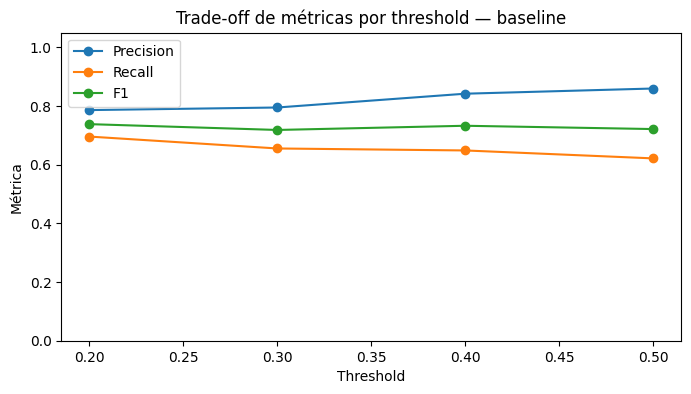

In [ ]:
# 16.1 Comparação de thresholds do baseline

thresholds = [0.50, 0.40, 0.30, 0.20]
resultados_threshold = []

for threshold in thresholds:
    pred_threshold = (y_score_baseline >= threshold).astype(int)

    metricas = calcular_metricas(
        f"Baseline — threshold {threshold:.2f}",
        y_test,
        pred_threshold,
        y_score_baseline,
    )

    resultados_threshold.append({
        "Threshold": threshold,
        "Precision": metricas["Precision"],
        "Recall": metricas["Recall"],
        "F1": metricas["F1"],
        "FP": metricas["FP"],
        "FN": metricas["FN"],
        "TP": metricas["TP"],
    })

comparacao_thresholds = pd.DataFrame(resultados_threshold)

comparacao_thresholds_exibicao = comparacao_thresholds.copy()

comparacao_thresholds_exibicao["Threshold"] = (
    comparacao_thresholds_exibicao["Threshold"]
    .map(lambda x: f"{x:.2f}".replace(".", ","))
)

for coluna in ["Precision", "Recall", "F1"]:
    comparacao_thresholds_exibicao[coluna] = (
        comparacao_thresholds_exibicao[coluna]
        .map(lambda x: f"{x:.4f}".replace(".", ","))
    )

for coluna in ["FP", "FN", "TP"]:
    comparacao_thresholds_exibicao[coluna] = (
        comparacao_thresholds_exibicao[coluna]
        .map(lambda x: f"{int(x):,}".replace(",", "."))
    )

display(comparacao_thresholds_exibicao)

metricas_plot = (
    comparacao_thresholds
    .sort_values("Threshold")
    .set_index("Threshold")[["Precision", "Recall", "F1"]]
)

metricas_plot.plot(
    marker="o",
    figsize=(8, 4),
    title="Trade-off de métricas por threshold — baseline",
)

plt.xlabel("Threshold")
plt.ylabel("Métrica")
plt.ylim(0, 1.05)
plt.show()


**Síntese pós-execução:** reduzir o threshold do baseline aumentou o recall de **0,6216 (0,50)** para **0,6959 (0,20)**, reduzindo falsos negativos de **56 para 45**, enquanto os falsos positivos aumentaram de **15 para 28** e a precision caiu de **0,8598 para 0,7863**. Entre os thresholds testados, `0,20` apresentou o maior F1 (**0,7384**), mas a escolha operacional não deve ser feita apenas por esse valor.


### Checkpoint 4 — Baseline, avaliação e decisão operacional

**Referência cumulativa:** os Checkpoints 1–3 permanecem como base de qualidade, exploração e preparação. Este checkpoint registra apenas as novas evidências das seções 11–16.

- **Baseline — Regressão Logística:** convergiu em **19 iterações** de um limite de 1.000. No teste preservado obteve **precision 0,8598**, **recall 0,6216**, **F1 0,7216**, **ROC-AUC 0,9566** e **Average Precision 0,7095**.
- **Erros do baseline:** **92 TP**, **15 FP**, **56 FN** e **85.280 TN**. A acurácia de **0,9992** não é suficiente para julgar o modelo porque a classe fraude representa apenas ~0,17% do teste.
- **ROC e Precision-Recall:** a ROC-AUC indica boa capacidade geral de separação, enquanto a Average Precision fornece uma leitura mais exigente para a classe rara e permanece muito acima da prevalência de fraude do teste.
- **Undersampling 1:1 no treino:** elevou o recall para **0,8784** e reduziu FN para **18**, porém a precision caiu para **0,0584** e os FP subiram para **2.096**. O ganho de sensibilidade veio acompanhado de forte deterioração na qualidade dos alertas.
- **Random Forest com pesos balanceados:** obteve **precision 0,8370**, **recall 0,7635**, **F1 0,7986**, **ROC-AUC 0,9683** e **Average Precision 0,7881**, com **22 FP** e **35 FN**. Foi o equilíbrio mais consistente deste bloco entre detectar fraudes e limitar falsos alertas.
- **Threshold do baseline:** ao reduzir de `0,50` para `0,20`, o recall aumentou de **0,6216** para **0,6959** e os FN caíram de **56 para 45**, enquanto os FP aumentaram de **15 para 28** e a precision caiu de **0,8598 para 0,7863**. O maior F1 entre os thresholds testados foi **0,7384** em `0,20`.
- **Deliberação do bloco:** undersampling mostrou que maximizar recall isoladamente pode gerar custo operacional excessivo. O ajuste de threshold oferece uma mudança mais moderada no baseline. O Random Forest, até aqui, apresenta a combinação mais forte de recall, precision, F1 e Average Precision, mas nenhuma estratégia é promovida como definitiva antes da comparação com os modelos avançados do próximo bloco.

**Conclusão:** o bloco confirma que decisões em fraude devem considerar simultaneamente fraudes detectadas, fraudes perdidas e falsos alertas. O mesmo conjunto de teste permaneceu preservado em todas as comparações.


## 17. XGBoost

O próximo modelo é o **XGBoost**, apresentado no 5.8 como uma abordagem de *boosting*: árvores são treinadas em sequência e cada nova etapa procura corrigir erros das anteriores.

A comparação será feita no mesmo conjunto de teste preservado. Os números mostrados pela docente permanecem **exemplos didáticos**, não metas a reproduzir.

### Referência ao Módulo 05

- **5.8 — Detecção de Anomalias em Transações:** XGBoost, boosting sequencial, comparação de precision/recall/F1 e uso em problemas de fraude.

Como o treino continua fortemente desbalanceado, será usada a razão entre classes (`scale_pos_weight`) como ponderação inicial. Isso preserva todos os registros do treino e dá maior peso aos exemplos raros sem criar observações sintéticas.

**Critério desta etapa:** verificar se o XGBoost melhora o equilíbrio entre detecção de fraudes, qualidade dos alertas e capacidade de ordenação frente ao Random Forest e ao baseline.


### 17.1 Treinamento e avaliação do XGBoost

O modelo inicial usa profundidade moderada e 100 árvores. Serão registrados o tempo de treinamento e as mesmas métricas adotadas desde o baseline, garantindo comparação direta.


In [ ]:
# 17.1 Treinamento e avaliação do XGBoost

from time import perf_counter

pre_requisitos_17 = [
    "pd",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "metricas_baseline",
    "metricas_rf",
    "calcular_metricas",
    "RANDOM_STATE",
]

faltantes_17 = [
    nome for nome in pre_requisitos_17
    if nome not in globals()
]

if faltantes_17:
    raise RuntimeError(
        "O runtime do Colab não contém os objetos necessários para a seção 17. "
        "Isso normalmente ocorre após reinício/desconexão do runtime. "
        "Reexecute as células do notebook de 0 até 16.1 antes de rodar 17.1. "
        f"Objetos ausentes: {faltantes_17}"
    )

try:
    from xgboost import XGBClassifier
except ImportError as exc:
    raise ImportError(
        "XGBoost não está disponível neste ambiente. "
        "A instalação de software não é realizada pelo Assessor Acadêmico."
    ) from exc

negativos_treino = int((y_train == 0).sum())
positivos_treino = int((y_train == 1).sum())
scale_pos_weight = negativos_treino / positivos_treino

modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.10,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

inicio_xgb = perf_counter()
modelo_xgb.fit(X_train, y_train)
tempo_xgb = perf_counter() - inicio_xgb

y_pred_xgb = modelo_xgb.predict(X_test)
y_score_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

metricas_xgb = pd.DataFrame([
    calcular_metricas(
        "XGBoost — configuração inicial",
        y_test,
        y_pred_xgb,
        y_score_xgb,
    )
])

comparacao_xgb = pd.concat(
    [metricas_baseline, metricas_rf, metricas_xgb],
    ignore_index=True,
)

comparacao_xgb_exibicao = comparacao_xgb[
    ["Modelo", "Precision", "Recall", "F1", "ROC_AUC", "Average_Precision", "FP", "FN"]
].copy()

for coluna in ["Precision", "Recall", "F1", "ROC_AUC", "Average_Precision"]:
    comparacao_xgb_exibicao[coluna] = comparacao_xgb_exibicao[coluna].map(
        lambda x: f"{x:.4f}".replace(".", ",")
    )

for coluna in ["FP", "FN"]:
    comparacao_xgb_exibicao[coluna] = comparacao_xgb_exibicao[coluna].map(
        lambda x: f"{int(x):,}".replace(",", ".")
    )

display(comparacao_xgb_exibicao)

print(
    "scale_pos_weight utilizado: "
    f"{scale_pos_weight:.2f}".replace(".", ",")
)
print(
    "Tempo aproximado de treinamento do XGBoost: "
    f"{tempo_xgb:.2f} s".replace(".", ",")
)


,Modelo,Precision,Recall,F1,ROC_AUC,Average_Precision,FP,FN
0,Regressão Logística — baseline,"0,8598","0,6216","0,7216","0,9566","0,7095",15,56
1,Random Forest — class_weight balanced,"0,8370","0,7635","0,7986","0,9683","0,7881",22,35
2,XGBoost — configuração inicial,"0,2613","0,8581","0,4006","0,9765","0,7441",359,21


scale_pos_weight utilizado: 578,55
Tempo aproximado de treinamento do XGBoost: 3,18 s


**Síntese pós-execução:** o XGBoost inicial obteve **precision 0,2613**, **recall 0,8581**, **F1 0,4006**, **ROC-AUC 0,9765** e **Average Precision 0,7441**, com **359 falsos positivos** e **21 falsos negativos**. O `scale_pos_weight` calculado foi **578,55**. O modelo detectou mais fraudes que o Random Forest, mas com perda acentuada de precision e forte aumento de falsos alertas. O treinamento levou aproximadamente **3,18 s** nesta execução.


## 18. Ajuste de hiperparâmetros — GridSearchCV

Depois da configuração inicial, será usado `GridSearchCV` para testar combinações de hiperparâmetros **dentro do conjunto de treino**.

O conjunto de teste continua fora da seleção. Ele será usado somente depois que a melhor configuração for escolhida pela validação cruzada.

### Referências ao Módulo 05

- **5.7 — Boas Práticas, Testes e Otimização de Código em Python:** comparação controlada e avaliação reproduzível;
- **5.8 — Detecção de Anomalias em Transações:** `GridSearchCV`, `max_depth`, `n_estimators` e seleção por métrica.

O 5.8 demonstra seleção orientada por `recall`. Neste projeto, o Checkpoint 4 mostrou que perseguir recall isoladamente pode gerar excesso de falsos positivos. Por isso o `GridSearchCV` será orientado por **Average Precision**, métrica mais adequada para comparar o ranking probabilístico em um problema extremamente desbalanceado.

**Critério desta etapa:** escolher hiperparâmetros usando apenas treino/validação e verificar no teste se a melhoria se sustenta.


### 18.1 GridSearchCV do XGBoost

Serão testadas quatro combinações entre:

- `max_depth`: 3 ou 5;
- `n_estimators`: 50 ou 100.

Os demais parâmetros permanecem fixos para que o efeito da busca seja interpretável e o custo computacional fique controlado.


In [ ]:
# 18.1 GridSearchCV do XGBoost

pre_requisitos_18 = [
    "pd",
    "XGBClassifier",
    "X_train",
    "X_test",
    "y_train",
    "y_test",
    "scale_pos_weight",
    "metricas_rf",
    "metricas_xgb",
    "calcular_metricas",
    "perf_counter",
    "RANDOM_STATE",
]

faltantes_18 = [
    nome for nome in pre_requisitos_18
    if nome not in globals()
]

if faltantes_18:
    raise RuntimeError(
        "A seção 18 depende da execução bem-sucedida da seção 17 e do pipeline anterior. "
        "Reexecute 0–16.1 se o runtime foi reiniciado e, em seguida, execute 17.1 antes de 18.1. "
        f"Objetos ausentes: {faltantes_18}"
    )

from sklearn.model_selection import GridSearchCV

xgb_grid_base = XGBClassifier(
    learning_rate=0.10,
    subsample=0.80,
    colsample_bytree=0.80,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

param_grid_xgb = {
    "max_depth": [3, 5],
    "n_estimators": [50, 100],
}

grid_xgb = GridSearchCV(
    estimator=xgb_grid_base,
    param_grid=param_grid_xgb,
    scoring="average_precision",
    cv=3,
    n_jobs=-1,
    refit=True,
    return_train_score=False,
)

inicio_grid = perf_counter()
grid_xgb.fit(X_train, y_train)
tempo_grid_xgb = perf_counter() - inicio_grid

melhor_xgb = grid_xgb.best_estimator_

y_pred_xgb_tuned = melhor_xgb.predict(X_test)
y_score_xgb_tuned = melhor_xgb.predict_proba(X_test)[:, 1]

metricas_xgb_tuned = pd.DataFrame([
    calcular_metricas(
        "XGBoost — GridSearchCV",
        y_test,
        y_pred_xgb_tuned,
        y_score_xgb_tuned,
    )
])

resultado_grid = pd.DataFrame({
    "Item": [
        "Melhores hiperparâmetros",
        "Average Precision médio na validação cruzada",
        "Tempo total da busca",
    ],
    "Resultado": [
        str(grid_xgb.best_params_),
        f"{grid_xgb.best_score_:.4f}".replace(".", ","),
        f"{tempo_grid_xgb:.2f} s".replace(".", ","),
    ],
})

display(resultado_grid)

comparacao_tuning = pd.concat(
    [metricas_rf, metricas_xgb, metricas_xgb_tuned],
    ignore_index=True,
)

comparacao_tuning_exibicao = comparacao_tuning[
    ["Modelo", "Precision", "Recall", "F1", "ROC_AUC", "Average_Precision", "FP", "FN"]
].copy()

for coluna in ["Precision", "Recall", "F1", "ROC_AUC", "Average_Precision"]:
    comparacao_tuning_exibicao[coluna] = comparacao_tuning_exibicao[coluna].map(
        lambda x: f"{x:.4f}".replace(".", ",")
    )

for coluna in ["FP", "FN"]:
    comparacao_tuning_exibicao[coluna] = comparacao_tuning_exibicao[coluna].map(
        lambda x: f"{int(x):,}".replace(",", ".")
    )

display(comparacao_tuning_exibicao)


,Item,Resultado
0,Melhores hiperparâmetros,"{'max_depth': 5, 'n_estimators': 100}"
1,Average Precision médio na validação cruzada,"0,8363"
2,Tempo total da busca,"34,16 s"


,Modelo,Precision,Recall,F1,ROC_AUC,Average_Precision,FP,FN
0,Random Forest — class_weight balanced,"0,8370","0,7635","0,7986","0,9683","0,7881",22,35
1,XGBoost — configuração inicial,"0,2613","0,8581","0,4006","0,9765","0,7441",359,21
2,XGBoost — GridSearchCV,"0,6557","0,8108","0,7251","0,9717","0,8158",63,28


**Síntese pós-execução:** o `GridSearchCV` selecionou **`max_depth=5`** e **`n_estimators=100`**, com **Average Precision médio de 0,8363** na validação cruzada e tempo total de busca de aproximadamente **34,16 s**. No teste preservado, o XGBoost ajustado obteve **precision 0,6557**, **recall 0,8108**, **F1 0,7251**, **ROC-AUC 0,9717** e **Average Precision 0,8158**, com **63 FP** e **28 FN**. Em relação ao XGBoost inicial, o tuning reduziu fortemente os falsos positivos (**359 → 63**) e elevou precision, F1 e Average Precision, com redução moderada de recall (**0,8581 → 0,8108**).


## 19. Importância de variáveis e explicabilidade

Depois de avaliar desempenho, é necessário entender **quais variáveis influenciam o modelo** e como essa leitura se relaciona com a análise exploratória da seção 6.

### Referência ao Módulo 05

- **5.8 — Detecção de Anomalias em Transações:** importância global de variáveis e SHAP para explicabilidade.

A importância global mostra quais features são mais utilizadas pelo modelo. O SHAP procura detalhar direção e magnitude da contribuição das features nas previsões.

**Cuidado conceitual:** importância, correlação e SHAP medem coisas diferentes. Nenhuma delas, isoladamente, demonstra causalidade. Como `V1`–`V28` são componentes PCA anonimizados, a interpretação permanece estatística, e não semântica de negócio.

**Critério desta etapa:** identificar as features mais influentes, confrontá-las com as correlações observadas anteriormente e produzir explicabilidade sem transformar associação em causa.


### 19.1 Importância global e SHAP

A importância global será calculada a partir do melhor XGBoost encontrado na seção 18. Em seguida, as principais features serão comparadas com sua correlação linear com `Class`.

O SHAP será executado sobre uma amostra do teste para limitar custo computacional. Se a biblioteca não estiver disponível no ambiente, a importância global continuará válida e a ausência será registrada sem instalar software automaticamente.


,Importancia_XGBoost
V14,0.459748
V4,0.055507
V10,0.052828
V20,0.037462
Amount_log,0.031281
V12,0.025278
V8,0.024099
V13,0.022373
V3,0.020183
V21,0.019552


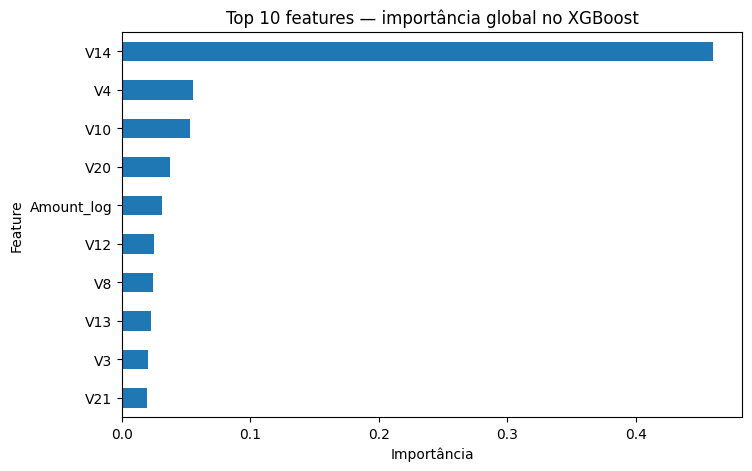

,Importancia_XGBoost,Correlacao_Class
V14,0.459748,-0.302544
V4,0.055507,0.133447
V10,0.052828,-0.216883
V20,0.037462,0.020090
Amount_log,0.031281,NaN
V12,0.025278,-0.260593
V8,0.024099,0.019875
V13,0.022373,-0.004570
V3,0.020183,-0.192961
V21,0.019552,0.040413


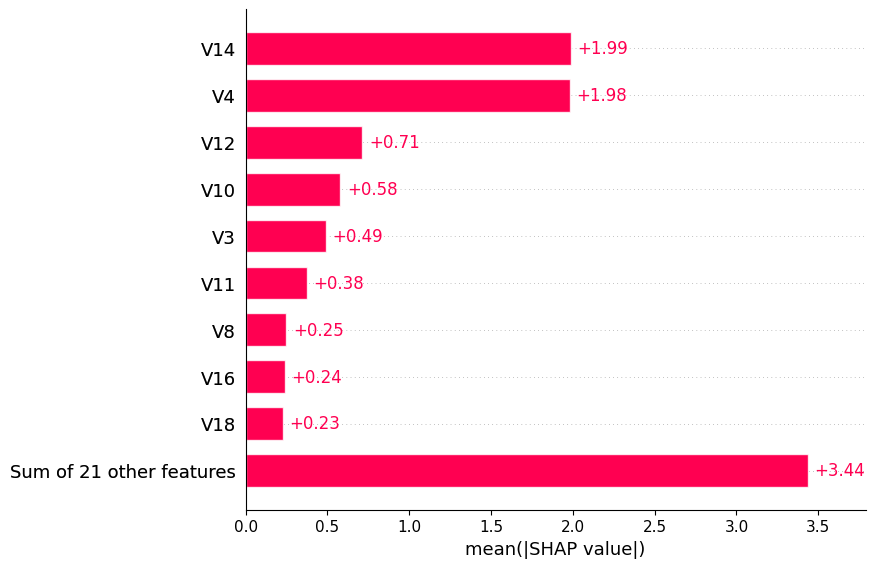

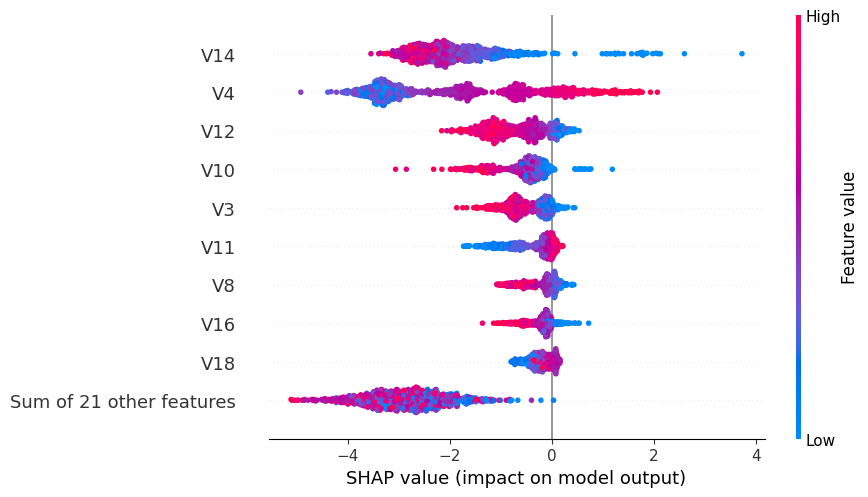

In [ ]:
# 19.1 Importância global e SHAP

pre_requisitos_19 = [
    "pd",
    "plt",
    "X_train",
    "X_test",
    "melhor_xgb",
    "RANDOM_STATE",
]

faltantes_19 = [
    nome for nome in pre_requisitos_19
    if nome not in globals()
]

if faltantes_19:
    raise RuntimeError(
        "A seção 19 depende da execução bem-sucedida das seções 17 e 18. "
        "Reexecute 0–16.1 se o runtime foi reiniciado, depois execute 17.1 e 18.1 antes de 19.1. "
        f"Objetos ausentes: {faltantes_19}"
    )

importancias_xgb = pd.Series(
    melhor_xgb.feature_importances_,
    index=X_train.columns,
    name="Importancia_XGBoost",
).sort_values(ascending=False)

top_importancias = importancias_xgb.head(10).to_frame()
display(top_importancias)

ax = (
    top_importancias
    .sort_values("Importancia_XGBoost")
    .plot(
        kind="barh",
        figsize=(8, 5),
        legend=False,
        title="Top 10 features — importância global no XGBoost",
    )
)
ax.set_xlabel("Importância")
ax.set_ylabel("Feature")
plt.show()

if "correlacoes" in globals():
    comparacao_explicabilidade = pd.DataFrame({
        "Importancia_XGBoost": importancias_xgb,
        "Correlacao_Class": correlacoes.reindex(importancias_xgb.index),
    }).loc[top_importancias.index]

    display(comparacao_explicabilidade)

try:
    import shap

    X_shap = X_test.sample(
        n=min(1000, len(X_test)),
        random_state=RANDOM_STATE,
    )

    explainer = shap.TreeExplainer(melhor_xgb)
    shap_values = explainer(X_shap)

    shap.plots.bar(
        shap_values,
        max_display=10,
        show=True,
    )

    shap.plots.beeswarm(
        shap_values,
        max_display=10,
        show=True,
    )

except ImportError:
    print(
        "SHAP não está disponível neste ambiente. "
        "A importância global do XGBoost foi mantida como evidência."
    )
except Exception as exc:
    print(
        "A etapa SHAP não pôde ser concluída neste ambiente: "
        f"{type(exc).__name__}: {exc}"
    )


**Síntese pós-execução:** na importância global do XGBoost, **V14** aparece muito à frente (**0,4597**), seguida por `V4` (**0,0555**), `V10` (**0,0528**), `V20` (**0,0375**) e `Amount_log` (**0,0313**). No SHAP, porém, **V14 e V4** apresentam impacto médio absoluto praticamente equivalente (aprox. **1,99** e **1,98**), seguidas por `V12`, `V10`, `V3` e `V11`. O beeswarm mostra direção coerente com várias correlações da seção 6: valores menores de `V14`, `V12`, `V10` e `V3` tendem a elevar a saída de fraude, enquanto valores maiores de `V4` e `V11` tendem a elevá-la. A diferença entre ranking por importância interna, correlação e SHAP é esperada porque cada método mede um aspecto diferente; nenhuma dessas medidas demonstra causalidade. `Amount_log` aparece sem correlação na tabela comparativa porque a série de correlações usada na seção 6 foi calculada antes da criação dessa feature, não porque sua correlação seja necessariamente nula.


### Checkpoint 5 — Modelos avançados, ajuste e explicabilidade

**Referência cumulativa:** o Checkpoint 4 permanece como referência para baseline, balanceamento, Random Forest e thresholds. Este checkpoint registra apenas as novas evidências das seções 17–19.

- **XGBoost inicial:** com `scale_pos_weight = 578,55`, obteve **precision 0,2613**, **recall 0,8581**, **F1 0,4006**, **ROC-AUC 0,9765** e **Average Precision 0,7441**, com **359 FP** e **21 FN**. O alto recall veio acompanhado de muitos falsos alertas.
- **GridSearchCV:** selecionou **`max_depth=5`** e **`n_estimators=100`**, com **Average Precision médio de 0,8363** na validação cruzada. No teste, o XGBoost ajustado atingiu **precision 0,6557**, **recall 0,8108**, **F1 0,7251**, **ROC-AUC 0,9717** e **Average Precision 0,8158**, com **63 FP** e **28 FN**.
- **Efeito do tuning:** frente ao XGBoost inicial, o ajuste reduziu **359 → 63 FP**, aumentou precision (**0,2613 → 0,6557**), F1 (**0,4006 → 0,7251**) e Average Precision (**0,7441 → 0,8158**), com redução moderada de recall (**0,8581 → 0,8108**).
- **Comparação com Random Forest:** o XGBoost ajustado detectou **120 das 148 fraudes** (28 FN), contra **113** do Random Forest (35 FN), mas produziu **63 FP** contra **22**. Assim, o XGBoost ajustado apresenta maior recall e Average Precision, enquanto o Random Forest mantém maior precision e F1.
- **Importância global:** `V14` foi dominante na importância interna do XGBoost (**0,4597**), seguida por `V4`, `V10`, `V20` e `Amount_log`.
- **SHAP:** `V14` e `V4` tiveram os maiores impactos médios absolutos, praticamente empatados; `V12`, `V10`, `V3` e `V11` vieram em seguida. Isso não replica exatamente a importância interna do modelo, o que é esperado.
- **Convergência com a EDA:** a direção observada no SHAP é coerente com várias correlações do Checkpoint 2 — valores menores de `V14`, `V12`, `V10` e `V3` tendem a elevar a saída de fraude, enquanto valores maiores de `V4` e `V11` tendem a elevá-la. A concordância reforça associação estatística, não causalidade.
- **Limitação de comparação:** `Amount_log` não possui valor na coluna de correlação exibida porque foi criada depois da análise de correlação da seção 6; o `NaN` representa ausência daquela medição anterior, não correlação zero.

**Conclusão do bloco:** o tuning tornou o XGBoost muito mais equilibrado do que sua configuração inicial. Frente ao Random Forest, não existe dominância em todas as métricas: o XGBoost ajustado favorece maior detecção e melhor Average Precision, enquanto o Random Forest preserva melhor precision, F1 e menor volume de falsos positivos. A escolha final depende do custo operacional dos dois tipos de erro e é consolidada na seção 26.


## 20. Qualidade do código e modularização

Com o fluxo analítico já funcional, esta etapa verifica regras simples de qualidade sem reescrever retroativamente o notebook inteiro.

### Referência ao Módulo 05

- **5.7 — Boas Práticas, Testes e Otimização de Código em Python:** funções pequenas, responsabilidades claras, validação e manutenção.

**Critério desta etapa:** centralizar validações reutilizáveis e confirmar que os principais objetos do pipeline mantêm estrutura compatível.


### 20.1 Validações reutilizáveis do pipeline

As funções abaixo validam colunas obrigatórias e alinhamento entre features e alvo. Elas não alteram dados nem modelos; apenas tornam explícitas regras que já usamos ao longo do notebook.


In [ ]:
# 20.1 Validações reutilizáveis do pipeline

def validar_colunas(dataframe, colunas_obrigatorias):
    faltantes = [
        coluna for coluna in colunas_obrigatorias
        if coluna not in dataframe.columns
    ]
    if faltantes:
        raise ValueError(
            f"Colunas obrigatórias ausentes: {faltantes}"
        )
    return True


def validar_alinhamento(features, alvo):
    if len(features) != len(alvo):
        raise ValueError(
            "Features e alvo possuem quantidades diferentes de registros."
        )
    if not features.index.equals(alvo.index):
        raise ValueError(
            "Índices de features e alvo não estão alinhados."
        )
    return True


validacoes_codigo = {
    "colunas_base": validar_colunas(
        df,
        ["Time", "Amount", "Class"],
    ),
    "alinhamento_treino": validar_alinhamento(
        X_train,
        y_train,
    ),
    "alinhamento_teste": validar_alinhamento(
        X_test,
        y_test,
    ),
}

display(pd.Series(validacoes_codigo, name="Validação"))


,Validação
colunas_base,True
alinhamento_treino,True
alinhamento_teste,True


**Síntese pós-execução:** as três validações retornaram `True`: as colunas-base existem e os pares `X_train/y_train` e `X_test/y_test` permanecem alinhados por quantidade e índice. A etapa confirma a integridade estrutural dos objetos usados na modelagem.


## 21. Testes mínimos do pipeline

Os testes verificam propriedades objetivas do fluxo já executado, evitando depender apenas de inspeção visual.

### Referência ao Módulo 05

- **5.7 — Boas Práticas, Testes e Otimização de Código em Python:** testes unitários e validação de comportamento esperado.

**Critério desta etapa:** testar invariantes relevantes — preservação de linhas, separação treino/teste, classes presentes e consistência dimensional — e auditar se registros duplicados idênticos atravessaram o split, risco levantado no Checkpoint 1.


### 21.1 Testes de integridade

Cada teste retorna `PASS` somente quando a propriedade é comprovada diretamente pelos objetos atuais do notebook.


In [ ]:
# 21.1 Testes de integridade

testes_pipeline = {
    "Amount_log preservou número de linhas":
        len(df_model) == len(df),

    "X e y possuem o mesmo número de registros":
        len(X) == len(y),

    "Treino e teste não compartilham índices":
        len(X_train.index.intersection(X_test.index)) == 0,

    "Treino contém as duas classes":
        set(y_train.unique()) == {0, 1},

    "Teste contém as duas classes":
        set(y_test.unique()) == {0, 1},

    "Treino escalado preservou dimensão":
        X_train_scaled.shape == X_train.shape,

    "Teste escalado preservou dimensão":
        X_test_scaled.shape == X_test.shape,
}

resultado_testes = pd.Series(
    {
        nome: "PASS" if passou else "FAIL"
        for nome, passou in testes_pipeline.items()
    },
    name="Resultado",
)

display(resultado_testes)

if not all(testes_pipeline.values()):
    falhas = [
        nome for nome, passou in testes_pipeline.items()
        if not passou
    ]
    raise AssertionError(
        f"Falhas nos testes estruturais do pipeline: {falhas}"
    )

# Auditoria adicional: registros idênticos podem ter índices diferentes.
treino_auditoria = X_train.copy()
treino_auditoria["Class"] = y_train

teste_auditoria = X_test.copy()
teste_auditoria["Class"] = y_test

hash_treino = pd.util.hash_pandas_object(
    treino_auditoria,
    index=False,
)
hash_teste = pd.util.hash_pandas_object(
    teste_auditoria,
    index=False,
)

hashes_compartilhados = set(hash_treino).intersection(
    set(hash_teste)
)

linhas_teste_com_equivalente_no_treino = int(
    hash_teste.isin(hashes_compartilhados).sum()
)

auditoria_duplicatas_split = pd.DataFrame({
    "Verificação": [
        "Padrões idênticos presentes em treino e teste",
        "Linhas do teste com equivalente idêntico no treino",
    ],
    "Resultado": [
        len(hashes_compartilhados),
        linhas_teste_com_equivalente_no_treino,
    ],
})

display(auditoria_duplicatas_split)

if hashes_compartilhados:
    print(
        "ATENÇÃO: existem registros idênticos atravessando treino e teste. "
        "Esse resultado deve ser tratado antes da deliberação técnica final."
    )
else:
    print(
        "Nenhum registro idêntico foi encontrado simultaneamente em treino e teste."
    )


,Resultado
Amount_log preservou número de linhas,PASS
X e y possuem o mesmo número de registros,PASS
Treino e teste não compartilham índices,PASS
Treino contém as duas classes,PASS
Teste contém as duas classes,PASS
Treino escalado preservou dimensão,PASS
Teste escalado preservou dimensão,PASS


,Verificação,Resultado
0,Padrões idênticos presentes em treino e teste,377
1,Linhas do teste com equivalente idêntico no tr...,456


ATENÇÃO: existem registros idênticos atravessando treino e teste. Esse resultado deve ser tratado antes da deliberação técnica final.


**Síntese pós-execução:** todos os testes estruturais retornaram `PASS`, mas a auditoria adicional encontrou **377 padrões idênticos presentes simultaneamente em treino e teste**, envolvendo **456 linhas do teste**. Portanto, índices distintos não foram suficientes para impedir sobreposição de conteúdo. Esse achado é material e exige uma análise de sensibilidade antes da deliberação final.


## 22. Performance e custo computacional

O objetivo não é micro-otimizar o notebook, mas registrar o custo das etapas de modelagem que realmente demandaram processamento.

### Referência ao Módulo 05

- **5.7 — Boas Práticas, Testes e Otimização de Código em Python:** profiling e medição antes de otimizar.

**Critério desta etapa:** comparar tempos já medidos sem reexecutar modelos apenas para obter cronometração.


### 22.1 Consolidação dos tempos de execução

Serão reunidos os tempos disponíveis para Random Forest, XGBoost e GridSearchCV. A busca de hiperparâmetros deve naturalmente custar mais porque treina várias combinações em validação cruzada.


,Etapa,Tempo_s
0,Random Forest — treino,"60,04"
1,XGBoost — treino inicial,"3,18"
2,XGBoost — GridSearchCV,"34,16"


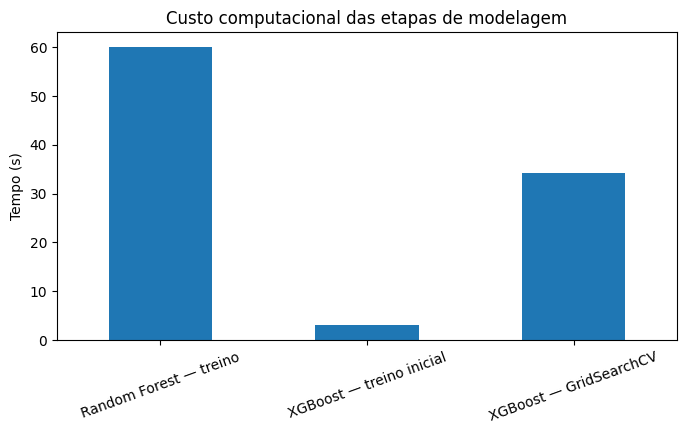

In [ ]:
# 22.1 Consolidação dos tempos de execução

tempos_modelagem = []

if "tempo_rf" in globals():
    tempos_modelagem.append({
        "Etapa": "Random Forest — treino",
        "Tempo_s": tempo_rf,
    })

if "tempo_xgb" in globals():
    tempos_modelagem.append({
        "Etapa": "XGBoost — treino inicial",
        "Tempo_s": tempo_xgb,
    })

if "tempo_grid_xgb" in globals():
    tempos_modelagem.append({
        "Etapa": "XGBoost — GridSearchCV",
        "Tempo_s": tempo_grid_xgb,
    })

tabela_tempos = pd.DataFrame(tempos_modelagem)

if tabela_tempos.empty:
    print("Nenhum tempo de modelagem registrado.")
else:
    tabela_tempos_exibicao = tabela_tempos.copy()
    tabela_tempos_exibicao["Tempo_s"] = (
        tabela_tempos_exibicao["Tempo_s"]
        .map(lambda x: f"{x:.2f}".replace(".", ","))
    )
    display(tabela_tempos_exibicao)

    ax = tabela_tempos.plot(
        x="Etapa",
        y="Tempo_s",
        kind="bar",
        legend=False,
        figsize=(8, 4),
        title="Custo computacional das etapas de modelagem",
        rot=20,
    )
    ax.set_xlabel("")
    ax.set_ylabel("Tempo (s)")
    plt.show()


**Síntese pós-execução:** os tempos consolidados da execução atual foram **60,04 s** para Random Forest, **3,18 s** para o XGBoost inicial e **34,16 s** para o GridSearchCV. Esses valores medem custo computacional da execução corrente e podem variar entre runtimes; não são métricas de qualidade preditiva.


## 23. Comparação consolidada dos modelos

Esta etapa reúne os principais experimentos em uma única tabela para permitir comparação direta.

A tabela deve ser interpretada como **evidência para decisão**, não como ranking automático. Em fraude, a preferência depende do custo relativo de falsos negativos e falsos positivos.

### Referências ao Módulo 05

- **5.7:** comparação objetiva de métricas;
- **5.8:** precision, recall, F1, ROC-AUC, Average Precision, balanceamento e threshold.

**Critério desta etapa:** consolidar resultados medidos no mesmo conjunto de teste e preservar o contexto de cada estratégia.


### 23.1 Tabela comparativa final

Além dos modelos principais, será incluída a Regressão Logística com threshold `0,20`, pois ela representa uma decisão operacional diferente sobre o mesmo modelo.

As siglas e métricas desta tabela seguem o **Guia de leitura das métricas da seção 12**. Assim, por exemplo, `FP` representa falsos alertas e `FN` representa fraudes reais não detectadas.


In [ ]:
# 23.1 Tabela comparativa final

pred_baseline_020 = (y_score_baseline >= 0.20).astype(int)

metricas_baseline_020 = pd.DataFrame([
    calcular_metricas(
        "Regressão Logística — threshold 0,20",
        y_test,
        pred_baseline_020,
        y_score_baseline,
    )
])

blocos_metricas = [
    metricas_baseline,
    metricas_baseline_020,
    metricas_under,
    metricas_rf,
]

if "metricas_xgb" in globals():
    blocos_metricas.append(metricas_xgb)

if "metricas_xgb_tuned" in globals():
    blocos_metricas.append(metricas_xgb_tuned)

tabela_final_numerica = pd.concat(
    blocos_metricas,
    ignore_index=True,
)

colunas_final = [
    "Modelo",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "Average_Precision",
    "FP",
    "FN",
    "TP",
]

tabela_final = tabela_final_numerica[colunas_final].copy()

tabela_final_exibicao = tabela_final.copy()

for coluna in ["Precision", "Recall", "F1", "ROC_AUC", "Average_Precision"]:
    tabela_final_exibicao[coluna] = (
        tabela_final_exibicao[coluna]
        .map(lambda x: f"{x:.4f}".replace(".", ","))
    )

for coluna in ["FP", "FN", "TP"]:
    tabela_final_exibicao[coluna] = (
        tabela_final_exibicao[coluna]
        .map(lambda x: f"{int(x):,}".replace(",", "."))
    )

display(tabela_final_exibicao)


,Modelo,Precision,Recall,F1,ROC_AUC,Average_Precision,FP,FN,TP
0,Regressão Logística — baseline,"0,8598","0,6216","0,7216","0,9566","0,7095",15,56,92
1,"Regressão Logística — threshold 0,20","0,7863","0,6959","0,7384","0,9566","0,7095",28,45,103
2,Regressão Logística — undersampling,"0,0584","0,8784","0,1095","0,9710","0,5471",2.096,18,130
3,Random Forest — class_weight balanced,"0,8370","0,7635","0,7986","0,9683","0,7881",22,35,113
4,XGBoost — configuração inicial,"0,2613","0,8581","0,4006","0,9765","0,7441",359,21,127
5,XGBoost — GridSearchCV,"0,6557","0,8108","0,7251","0,9717","0,8158",63,28,120


**Síntese pós-execução:** a tabela consolidada confirma os trade-offs já observados: o **Random Forest** apresenta o maior F1 (**0,7986**) e alta precision (**0,8370**); o **XGBoost ajustado** apresenta maior recall (**0,8108**) e maior Average Precision (**0,8158**) entre os modelos finais comparáveis, porém com mais falsos positivos (**63 vs. 22**). O undersampling maximiza recall, mas com **2.096 FP**. Estes números ainda pertencem ao teste original e serão submetidos à análise de sensibilidade de duplicatas.


## 24. Storytelling técnico

A síntese visual final deve responder a uma pergunta clara, sem repetir todos os gráficos anteriores.

### Referência ao Módulo 05

- **5.6 — Visualização Avançada de Dados com Python:** escolha de gráficos coerentes com a mensagem e construção de narrativa;
- **5.8 — Detecção de Anomalias em Transações:** comparação de métricas e interpretação do trade-off entre precision e recall.

**Pergunta escolhida:** como os principais modelos e estratégias equilibram **precision, recall e F1** no mesmo conjunto de teste?


### 24.1 Comparação visual de precision, recall e F1

O gráfico final coloca as três métricas lado a lado para evidenciar o trade-off de cada estratégia. Ele complementa a tabela da seção 23 e não substitui a análise de falsos positivos e falsos negativos.


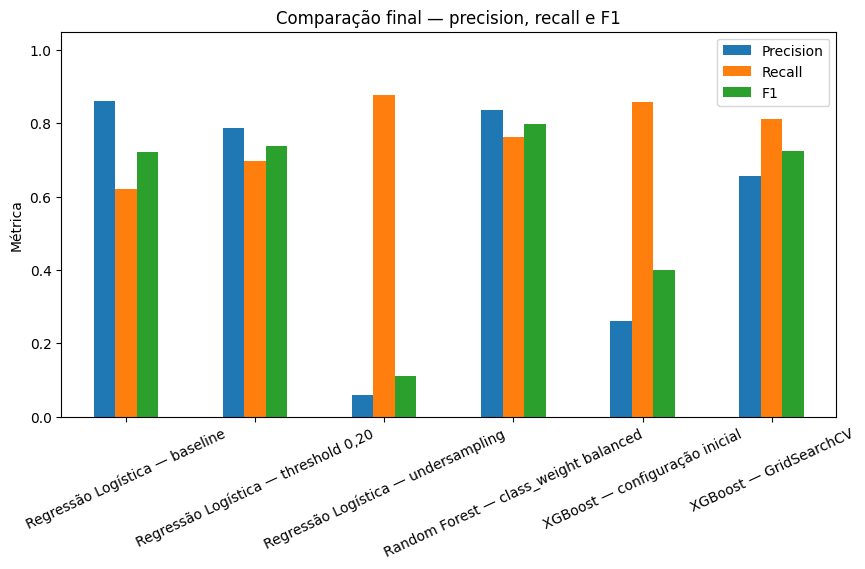

In [ ]:
# 24.1 Comparação visual de precision, recall e F1

metricas_story = (
    tabela_final_numerica
    .set_index("Modelo")[["Precision", "Recall", "F1"]]
)

ax = metricas_story.plot(
    kind="bar",
    figsize=(10, 5),
    rot=25,
    title="Comparação final — precision, recall e F1",
)

ax.set_xlabel("")
ax.set_ylabel("Métrica")
ax.set_ylim(0, 1.05)
plt.legend(title="")
plt.show()


**Síntese pós-execução:** a comparação visual de precision, recall e F1 reforça que não existe dominância universal: estratégias mais agressivas elevam recall às custas de precision, enquanto o Random Forest preserva o melhor equilíbrio de F1. O gráfico funciona como síntese do trade-off, mas a decisão final depende também de FP/FN e da auditoria de duplicatas.


## 25. Validação final

Esta etapa verifica completude estrutural, trata a sobreposição de duplicatas detectada entre treino e teste e libera — ou bloqueia — a deliberação final.

### Referências ao Módulo 05

- **5.6:** comunicação e storytelling;
- **5.7:** validação e qualidade;
- **5.8:** comparação de modelos, explicabilidade e síntese do problema de fraude.

**Critério desta etapa:** não transformar presença de objetos em evidência de validade metodológica. A conclusão só é liberada após tratar o alerta de duplicatas.


### 25.1 Gate estrutural e alerta de duplicatas

Este gate confirma a presença das principais evidências e explicita se ainda existe alerta metodológico. `PASS` estrutural não substitui a análise de sensibilidade da seção 25.2.


In [ ]:
# 25.1 Gate estrutural e alerta de duplicatas

checks_estruturais = {
    "dataset_carregado": "df" in globals(),
    "feature_engineering": "Amount_log" in df_model.columns,
    "split_executado": all(
        nome in globals()
        for nome in ["X_train", "X_test", "y_train", "y_test"]
    ),
    "baseline_avaliado": "metricas_baseline" in globals(),
    "random_forest_avaliado": "metricas_rf" in globals(),
    "xgboost_avaliado": "metricas_xgb" in globals(),
    "grid_search_executado": "metricas_xgb_tuned" in globals(),
    "explicabilidade_global": "importancias_xgb" in globals(),
    "tabela_comparativa": "tabela_final_numerica" in globals(),
    "auditoria_duplicatas_executada": "auditoria_duplicatas_split" in globals(),
}

sobreposicao_duplicatas = (
    len(hashes_compartilhados)
    if "hashes_compartilhados" in globals()
    else None
)

sensibilidade_pronta = (
    sobreposicao_duplicatas == 0
    or "tabela_sensibilidade_duplicatas" in globals()
)

status_gate = {
    nome: "PASS" if valor else "PENDENTE"
    for nome, valor in checks_estruturais.items()
}

status_gate["sobreposicao_duplicatas_treino_teste"] = (
    "PASS" if sobreposicao_duplicatas == 0 else "ALERTA"
)
status_gate["sensibilidade_sem_sobreposicao"] = (
    "PASS" if sensibilidade_pronta else "PENDENTE"
)

resultado_gate = pd.Series(status_gate, name="Status")
display(resultado_gate)

liberacao_estrutural = all(checks_estruturais.values())

if liberacao_estrutural and sensibilidade_pronta:
    print(
        "Evidências estruturais e tratamento da sobreposição de duplicatas "
        "presentes para a deliberação técnica final."
    )
else:
    print(
        "Gate final ainda bloqueado: conclua os itens marcados como PENDENTE "
        "e trate o ALERTA de duplicatas antes da deliberação final."
    )


,Status
dataset_carregado,PASS
feature_engineering,PASS
split_executado,PASS
baseline_avaliado,PASS
random_forest_avaliado,PASS
xgboost_avaliado,PASS
grid_search_executado,PASS
explicabilidade_global,PASS
tabela_comparativa,PASS
auditoria_duplicatas_executada,PASS


Gate final ainda bloqueado: conclua os itens marcados como PENDENTE e trate o ALERTA de duplicatas antes da deliberação final.


**Síntese pós-execução:** o gate estrutural confirmou todos os objetos e evidências esperados, mas marcou corretamente a sobreposição de duplicatas como **ALERTA** e a análise de sensibilidade como **PENDENTE** naquele momento. O gate não foi interpretado como liberação metodológica até a execução da seção 25.2.


### 25.2 Análise de sensibilidade sem sobreposição de duplicatas

A auditoria da seção 21 identificou registros idênticos simultaneamente em treino e teste. Antes de alterar o split ou remover dados, esta análise mede quanto isso afeta as conclusões já obtidas.

A estratégia é conservadora: **não retreina os modelos**. Apenas exclui da avaliação as linhas do teste que possuem equivalente idêntico no treino e recalcula as métricas sobre a parcela não contaminada.

**Critério:** se o comportamento relativo dos modelos permanecer semelhante, a sobreposição é registrada como limitação controlada; se houver mudança material no ranking ou nas conclusões, o fluxo deve voltar à divisão treino/teste e adotar um split por grupos idênticos antes de novo treinamento.


In [ ]:
# 25.2 Análise de sensibilidade sem sobreposição de duplicatas

if "hash_teste" not in globals() or "hashes_compartilhados" not in globals():
    raise RuntimeError(
        "Execute a seção 21.1 antes da análise de sensibilidade de duplicatas."
    )

mascara_teste_limpo = ~hash_teste.isin(hashes_compartilhados)
mascara_teste_limpo_np = mascara_teste_limpo.to_numpy()

y_test_limpo = y_test.loc[mascara_teste_limpo.index[mascara_teste_limpo]]

removidos = y_test.loc[mascara_teste_limpo.index[~mascara_teste_limpo]]

resumo_remocao_duplicatas = pd.DataFrame({
    "Item": [
        "Linhas originais do teste",
        "Linhas excluídas por sobreposição idêntica",
        "Linhas mantidas na avaliação limpa",
        "Classe 0 excluída",
        "Classe 1 excluída",
    ],
    "Resultado": [
        len(y_test),
        int((~mascara_teste_limpo).sum()),
        int(mascara_teste_limpo.sum()),
        int((removidos == 0).sum()),
        int((removidos == 1).sum()),
    ],
})

display(resumo_remocao_duplicatas)

def metricas_em_teste_limpo(nome, y_pred, y_score):
    return calcular_metricas(
        nome,
        y_test_limpo,
        y_pred[mascara_teste_limpo_np],
        y_score[mascara_teste_limpo_np],
    )

linhas_sensibilidade = [
    metricas_em_teste_limpo(
        "Regressão Logística — baseline",
        y_pred_baseline,
        y_score_baseline,
    ),
    metricas_em_teste_limpo(
        "Regressão Logística — threshold 0,20",
        (y_score_baseline >= 0.20).astype(int),
        y_score_baseline,
    ),
    metricas_em_teste_limpo(
        "Regressão Logística — undersampling",
        y_pred_under,
        y_score_under,
    ),
    metricas_em_teste_limpo(
        "Random Forest — class_weight balanced",
        y_pred_rf,
        y_score_rf,
    ),
    metricas_em_teste_limpo(
        "XGBoost — configuração inicial",
        y_pred_xgb,
        y_score_xgb,
    ),
    metricas_em_teste_limpo(
        "XGBoost — GridSearchCV",
        y_pred_xgb_tuned,
        y_score_xgb_tuned,
    ),
]

tabela_sensibilidade_duplicatas = pd.DataFrame(linhas_sensibilidade)

colunas_sensibilidade = [
    "Modelo", "Precision", "Recall", "F1",
    "ROC_AUC", "Average_Precision", "FP", "FN", "TP"
]

exibicao_sensibilidade = tabela_sensibilidade_duplicatas[
    colunas_sensibilidade
].copy()

for coluna in ["Precision", "Recall", "F1", "ROC_AUC", "Average_Precision"]:
    exibicao_sensibilidade[coluna] = exibicao_sensibilidade[coluna].map(
        lambda x: f"{x:.4f}".replace(".", ",")
    )

for coluna in ["FP", "FN", "TP"]:
    exibicao_sensibilidade[coluna] = exibicao_sensibilidade[coluna].map(
        lambda x: f"{int(x):,}".replace(",", ".")
    )

display(exibicao_sensibilidade)


,Item,Resultado
0,Linhas originais do teste,85443
1,Linhas excluídas por sobreposição idêntica,456
2,Linhas mantidas na avaliação limpa,84987
3,Classe 0 excluída,449
4,Classe 1 excluída,7


,Modelo,Precision,Recall,F1,ROC_AUC,Average_Precision,FP,FN,TP
0,Regressão Logística — baseline,"0,8500","0,6028","0,7054","0,9545","0,6876",15,56,85
1,"Regressão Logística — threshold 0,20","0,7742","0,6809","0,7245","0,9545","0,6876",28,45,96
2,Regressão Logística — undersampling,"0,0560","0,8723","0,1052","0,9696","0,5197",2.075,18,123
3,Random Forest — class_weight balanced,"0,8346","0,7518","0,7910","0,9667","0,7730",21,35,106
4,XGBoost — configuração inicial,"0,2516","0,8511","0,3883","0,9754","0,7266",357,21,120
5,XGBoost — GridSearchCV,"0,6457","0,8014","0,7152","0,9703","0,8052",62,28,113


**Síntese pós-execução:** a avaliação limpa removeu **456 linhas** do teste com equivalente idêntico no treino — **449 da classe 0** e **7 da classe 1** — mantendo **84.987 registros**. As métricas caíram de forma pequena e consistente, mas o comportamento relativo dos modelos permaneceu estável. No conjunto limpo, o Random Forest manteve o maior F1 (**0,7910**) com **21 FP** e **35 FN**; o XGBoost ajustado manteve maior recall (**0,8014**) e Average Precision (**0,8052**), com **62 FP** e **28 FN**. O undersampling continuou com recall alto (**0,8723**) e precision muito baixa (**0,0560**). A sobreposição inflava levemente a avaliação, mas não alterou as conclusões centrais; por isso é tratada como **limitação controlada**, sem necessidade de refazer todo o treinamento neste material.


### 25.3 Gate metodológico final

Depois da análise de sensibilidade, este gate confirma se existe evidência suficiente para redigir a deliberação final. Ele não escolhe automaticamente um modelo; apenas verifica se a principal limitação detectada foi efetivamente analisada.


In [ ]:
# 25.3 Gate metodológico final

requisitos_finais = {
    "estrutura_completa": (
        "checks_estruturais" in globals()
        and all(checks_estruturais.values())
    ),
    "auditoria_duplicatas_executada": (
        "auditoria_duplicatas_split" in globals()
    ),
    "sensibilidade_duplicatas_executada": (
        "tabela_sensibilidade_duplicatas" in globals()
    ),
    "checkpoint_5_suportado": (
        "metricas_xgb_tuned" in globals()
        and "importancias_xgb" in globals()
    ),
}

status_final = pd.Series(
    {
        nome: "PASS" if valor else "PENDENTE"
        for nome, valor in requisitos_finais.items()
    },
    name="Status",
)

display(status_final)

if all(requisitos_finais.values()):
    print(
        "Gate metodológico liberado para a deliberação técnica final."
    )
else:
    print(
        "Deliberação final ainda bloqueada por evidência pendente."
    )


,Status
estrutura_completa,PASS
auditoria_duplicatas_executada,PASS
sensibilidade_duplicatas_executada,PASS
checkpoint_5_suportado,PASS


Gate metodológico liberado para a deliberação técnica final.


**Síntese pós-execução:** todos os requisitos metodológicos retornaram **PASS**. A auditoria de duplicatas foi executada, seu efeito foi medido por análise de sensibilidade e as conclusões permaneceram estáveis. O gate metodológico está liberado para a deliberação técnica final.


### Checkpoint 6 — Qualidade, validação e consolidação final do pipeline

**Referência cumulativa:** os Checkpoints 1–5 permanecem como histórico de qualidade, exploração, preparação, modelagem e explicabilidade. Este checkpoint fecha apenas as evidências das seções 20–25.

- **Qualidade estrutural:** validações de colunas, alinhamento, dimensões e presença das classes foram aprovadas.
- **Auditoria de duplicatas:** foram identificados **377 padrões idênticos** simultaneamente em treino e teste, envolvendo **456 linhas do teste**.
- **Análise de sensibilidade:** a avaliação foi repetida sem essas 456 linhas. Permaneceram **84.987 registros**, com exclusão de **449 normais** e **7 fraudes**.
- **Robustez das conclusões:** as métricas sofreram pequenas reduções, mas nenhum trade-off central foi invertido. O Random Forest permaneceu com o maior F1 e baixo número de falsos positivos; o XGBoost ajustado permaneceu com maior recall e Average Precision; o undersampling permaneceu inadequado quando considerado o volume de falsos alertas.
- **Efeito específico das duplicatas:** os sete registros fraudulentos removidos haviam sido verdadeiros positivos em todos os modelos; os falsos negativos permaneceram inalterados. A sobreposição elevava levemente os resultados, mas não sustentava sozinha a comparação entre modelos.
- **Performance:** tempos de execução foram registrados como evidência operacional dependente do runtime, não como qualidade preditiva.
- **Comparação e storytelling:** tabelas e visualizações finais estão consistentes com as métricas e com o guia de nomenclatura da seção 12.
- **Gate metodológico:** todos os requisitos da seção 25.3 retornaram `PASS`.

**Conclusão do bloco:** a sobreposição de duplicatas constitui uma limitação real, porém seu impacto foi quantificado e não alterou materialmente as conclusões. Para este material de treino orientado, a limitação está controlada e não exige refazer todo o pipeline. Em uma avaliação de produção ou benchmark formal, a prática preferível seria realizar o split por grupos de registros idênticos antes do treinamento.


## 26. Deliberação final

Esta seção consolida os Checkpoints 1–6 por referência e encerra tecnicamente o notebook. A conclusão utiliza como evidência conservadora a análise de sensibilidade da seção 25.2, na qual registros idênticos presentes simultaneamente em treino e teste foram retirados da avaliação.

### 26.1 Cobertura do conteúdo do 5.8

A revisão das três transcrições do 5.8 mostra cobertura dos principais tópicos do curso: carregamento e interpretação do dataset; desbalanceamento; precision/recall; `Amount_log`; padronização; `X/y`; split 70/30 estratificado; Regressão Logística; matriz/métricas; ROC e Precision-Recall; undersampling e discussão de oversampling; Random Forest; ajuste de threshold; XGBoost; GridSearchCV; importância de features e SHAP.

**Diferenças metodológicas deliberadas:**
- o scaler foi ajustado apenas no treino, reduzindo risco de leakage;
- a seleção do GridSearchCV usou **Average Precision**, e não recall isolado, porque nossos próprios experimentos mostraram o custo de perseguir recall sem controlar falsos positivos;
- a implementação usa etapas explícitas em vez de um objeto `Pipeline` do scikit-learn, preservando a mesma lógica de processamento com maior visibilidade pedagógica;
- oversampling foi abordado conceitualmente, mas não adotado como experimento principal; foram testadas estratégias de undersampling, pesos de classe e threshold;
- foi acrescentada auditoria de duplicatas entre treino e teste, ausente no fluxo apresentado na transcrição.

**Cobertura adicional do notebook:** nulos, infinitos, duplicatas, estatística descritiva, `Amount = 0`, comportamento temporal, correlações, prevenção explícita de leakage, testes de integridade, profiling e análise de sensibilidade de duplicatas.

### 26.2 Conclusão técnica integrada

O projeto analisou **284.807 transações**, das quais apenas **492** pertencem à classe fraude — aproximadamente **0,1727%** da base. Esse desbalanceamento confirmou desde o início que acurácia isolada não seria um critério suficiente.

A qualidade inicial não apresentou valores nulos nem infinitos, mas revelou **1.081 duplicatas excedentes**. A análise exploratória mostrou forte assimetria em `Amount`, presença de registros com `Amount = 0`, sinais temporais exploratórios e associações lineares relevantes sobretudo em variáveis como `V17`, `V14`, `V12` e `V10`.

A transformação `log1p` reduziu a assimetria de `Amount` de **16,9777** para **0,1627**, preservando os **1.825 registros com valor zero**. A modelagem passou a usar `Time`, `V1`–`V28` e `Amount_log`. O split 70/30 preservou a proporção da classe rara e o `StandardScaler` foi ajustado exclusivamente no treino, evitando leakage estatístico pela padronização.

A Regressão Logística forneceu o baseline. Estratégias posteriores mostraram que aumentar recall sem considerar precision pode ser operacionalmente inadequado: o undersampling alcançou recall elevado, mas gerou milhares de falsos positivos. O ajuste de threshold permitiu mudanças mais graduais.

Entre os modelos principais, a avaliação conservadora sem linhas duplicadas entre treino e teste apresentou:

| Modelo / estratégia | Precision | Recall | F1 | Average Precision | FP | FN |
|---|---:|---:|---:|---:|---:|---:|
| Regressão Logística — baseline | 0,8500 | 0,6028 | 0,7054 | 0,6876 | 15 | 56 |
| Regressão Logística — threshold 0,20 | 0,7742 | 0,6809 | 0,7245 | 0,6876 | 28 | 45 |
| Undersampling | 0,0560 | 0,8723 | 0,1052 | 0,5197 | 2.075 | 18 |
| Random Forest — pesos balanceados | **0,8346** | 0,7518 | **0,7910** | 0,7730 | **21** | 35 |
| XGBoost — inicial | 0,2516 | 0,8511 | 0,3883 | 0,7266 | 357 | 21 |
| XGBoost — GridSearchCV | 0,6457 | **0,8014** | 0,7152 | **0,8052** | 62 | **28** |

Não existe dominância universal. O **Random Forest** permanece como a referência mais equilibrada quando o objetivo é combinar boa detecção com alta qualidade dos alertas: apresenta o maior F1 entre os modelos comparados, precision elevada e apenas 21 falsos positivos na avaliação limpa. O **XGBoost ajustado** é uma alternativa quando a prioridade operacional é capturar mais fraudes: reduz falsos negativos de 35 para 28 e alcança maior recall e Average Precision, ao custo de elevar falsos positivos de 21 para 62.

A explicabilidade reforçou a relevância de `V14` e `V4`, também destacadas pelo SHAP. Correlação, importância interna do modelo e valores SHAP mostraram convergências, mas não são equivalentes e não demonstram causalidade. Como `V1`–`V28` são componentes PCA anonimizados, a interpretação deve permanecer estatística.

A auditoria final identificou **377 padrões idênticos** presentes nos dois lados do split. Ao remover da avaliação as **456 linhas do teste** afetadas — incluindo **7 fraudes** — houve redução pequena das métricas, porém nenhuma alteração material no comportamento relativo dos modelos. Os sete registros fraudulentos removidos haviam sido classificados corretamente por todos os modelos, e os falsos negativos permaneceram iguais. Assim, a sobreposição é registrada como **limitação controlada**, e não como motivo para invalidar o aprendizado deste notebook. Para um uso de produção, benchmark formal ou decisão de alto impacto, a recomendação seria refazer o split por grupos idênticos antes do treinamento e repetir a avaliação.

**Deliberação técnica:** para este notebook de treino orientado, o processo está tecnicamente fechado e as evidências são suficientes para sustentar a conclusão. O Random Forest é a referência operacional mais equilibrada neste conjunto de experimentos, enquanto o XGBoost ajustado representa a alternativa orientada a maior sensibilidade à fraude.

**Limitações principais:** forte desbalanceamento, componentes PCA sem semântica de negócio, janela temporal curta do dataset, duplicatas de conteúdo no split original e ausência de custo financeiro real para converter FP/FN em uma função de decisão econômica.

**Próximos passos recomendados para um projeto de produção:** split por grupos ou deduplicação controlada antes da modelagem; validação temporal quando houver dados com cronologia operacional; calibração e escolha de threshold com custos reais; comparação de oversampling quando justificado; monitoramento de drift; e validação de explicabilidade em amostras de produção.
